In [16]:
# Imports and helper functions: flatten_csp, Fisher score, miBIF, mRMR, select_features, cv_aggregate_select

import os, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tkinter as tk
from tkinter import filedialog
from joblib import Parallel, delayed
import mne, yaml
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, roc_curve, auc, mutual_info_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from scipy.signal import butter, sosfilt
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
mne.set_log_level('WARNING')
def flatten_csp(X_csp, n_bands, n_comp):
    """Band-major flatten [n_win, n_bands, n_comp] → [n_win, n_bands*n_comp].
    Order: [band0_comp0..band0_compN | band1_comp0..band1_compN | ...]
    Matches Fbcsp.cpp column-major serialisation and flatten_csp() in training."""
    n_win = X_csp.shape[0]
    out = np.zeros((n_win, n_bands * n_comp))
    for b in range(n_bands):
        out[:, b * n_comp : (b + 1) * n_comp] = X_csp[:, b, :]
    return out
def get_fisher_score(X, y, classes):
    """Per-feature Fisher ratio: |µ1 - µ2|² / (σ1² + σ2²)."""
    mu1, mu2 = np.mean(X[y == classes[0]], 0), np.mean(X[y == classes[1]], 0)
    s1,  s2  = np.std( X[y == classes[0]], 0), np.std( X[y == classes[1]], 0)
    return np.abs(mu1 - mu2)**2 / (s1**2 + s2**2 + 1e-10)
def _mi_pair(x1, x2, n_bins=10):
    """Approximate MI between two continuous features by quantile-binning.
    Used by mRMR to estimate inter-feature redundancy.
    """
    edges = np.quantile(x1, np.linspace(0, 1, n_bins + 1)[1:-1])
    d1 = np.digitize(x1, edges)
    edges = np.quantile(x2, np.linspace(0, 1, n_bins + 1)[1:-1])
    d2 = np.digitize(x2, edges)
    return mutual_info_score(d1, d2)
def _score_relevance(X, y, classes, method, seed=42):
    """Per-feature class-discriminability score."""
    if method in ('mibif', 'mrmr'):
        return mutual_info_classif(X, y, random_state=seed)
    if method == 'fisher':
        return get_fisher_score(X, y, classes)
    raise ValueError(f'Unknown FS method: {method!r}')
def _adaptive_cap(scores, k_max, score_frac):
    """Indices of scores >= score_frac * top_score, capped at k_max.
    Returns picks in DESCENDING relevance order."""
    order = np.argsort(scores)[::-1]
    top   = scores[order[0]] if len(order) else 0.0
    if top <= 0:
        return order[:k_max]
    threshold = score_frac * top
    keep = [i for i in order[:k_max] if scores[i] >= threshold]
    return np.array(keep) if keep else order[:1]
def _select_mibif(scores, k_max, score_frac):
    return _adaptive_cap(scores, k_max, score_frac)
def _select_mrmr(X, relevance, k_max, score_frac):
    """mRMR (Peng et al., 2005): iteratively maximise
        relevance[f] - mean( MI(f, picked) )
    Early-stops when the next candidate's relevance falls below score_frac of
    the top relevance — so noisy candidates are not forced in.
    Returns picks in selection order (best first).
    """
    n_feat = X.shape[1]
    if k_max is None or k_max >= n_feat:
        return np.argsort(relevance)[::-1]
    selected = [int(np.argmax(relevance))]
    top_rel  = relevance[selected[0]]
    redundancy_acc = np.zeros(n_feat)
    while len(selected) < k_max:
        last = selected[-1]
        for f in range(n_feat):
            if f in selected:
                continue
            redundancy_acc[f] += _mi_pair(X[:, f], X[:, last])
        avg_red = redundancy_acc / len(selected)
        score   = relevance - avg_red
        score[selected] = -np.inf
        nxt     = int(np.argmax(score))
        if relevance[nxt] < score_frac * top_rel:
            break
        selected.append(nxt)
    return np.array(selected)
def select_features(X, y, classes, method, k_max, score_frac=0.2, seed=42):
    """Per-fold feature selection (used INSIDE the CV loop, no leakage).
    Returns (picks_in_order, relevance_scores). picks_in_order is in descending
    relevance / mRMR-score; sort it before storing in the YAML.
    """
    n_feat = X.shape[1]
    if method is None or k_max is None or k_max >= n_feat:
        return np.arange(n_feat), None
    relevance = _score_relevance(X, y, classes, method, seed=seed)
    if method in ('mibif', 'fisher'):
        picks = _select_mibif(relevance, k_max, score_frac)
    elif method == 'mrmr':
        picks = _select_mrmr(X, relevance, k_max, score_frac)
    else:
        raise ValueError(f'Unknown FS method: {method!r}')
    return picks, relevance
def cv_aggregate_select(X_folds, y_folds, classes, method, k_max,
                        score_frac=0.2, seed=42):
    """Cross-validated feature selection via VOTING.
    Step 1: each fold runs the chosen FS method on its TRAIN data only and picks
            its own feature set (already done inside the CV loop; we replay it
            here so this function is self-contained).
    Step 2: pick_count[f] = number of folds in which feature f survived FS.
    Step 3: features picked by the MAJORITY of folds (>= (K+1)//2) form the
            stable set, ordered by (pick_count DESC, mean_relevance DESC).
    Step 4: cap at k_max. If fewer than 2 stable features (rare with noisy data),
            fall back to top-K by mean relevance with adaptive cap.
    Returns (picks_in_order, mean_relevance, pick_count, fold_picks).
    picks_in_order is in descending stability/score order; sort before YAML.
    """
    n_feat  = X_folds[0].shape[1]
    n_folds = len(y_folds)
    if method is None or k_max is None or k_max >= n_feat:
        return (np.arange(n_feat), None,
                np.full(n_feat, n_folds, dtype=int), [])
    pick_count = np.zeros(n_feat, dtype=int)
    fold_rel   = []
    fold_picks = []
    for X, y in zip(X_folds, y_folds):
        rel   = _score_relevance(X, y, classes, method, seed=seed)
        picks = (_select_mrmr(X, rel, k_max, score_frac)
                 if method == 'mrmr'
                 else _select_mibif(rel, k_max, score_frac))
        pick_count[picks] += 1
        fold_rel.append(rel)
        fold_picks.append(picks)
    mean_rel = np.mean(fold_rel, axis=0)
    composite = pick_count.astype(float) + mean_rel / (mean_rel.max() + 1e-12)
    order     = np.argsort(composite)[::-1]
    majority = (n_folds + 1) // 2
    stable   = order[pick_count[order] >= majority]
    if len(stable) >= 2:
        picks_out = stable[:k_max]
    else:
        picks_out = _adaptive_cap(mean_rel, k_max, score_frac)
    return picks_out, mean_rel, pick_count, fold_picks


In [17]:
# File picker: GUI dialog to select one or more GDF calibration recordings

root = tk.Tk()
root.withdraw() 
current_dir = os.getcwd()
current_dir = os.path.dirname(current_dir)
current_dir = os.path.dirname(current_dir)
current_dir = os.path.dirname(current_dir)
filenames = filedialog.askopenfilenames(
    title="Seleziona i file GDF", 
    filetypes=[("GDF Files", "*.gdf")],
    initialdir=current_dir
)
if not filenames:
    print("Nessun file selezionato!")
else:
    print(f"Selezionati {len(filenames)} file:")
    for f in filenames:
        print(f" - {f}")
    paradigm = os.path.splitext(os.path.basename(filenames[0]))[0].split('.')[-1]
    subject = os.path.splitext(os.path.basename(filenames[0]))[0].split('.')[0]
    if 'cvsa' in paradigm.lower():
        paradigm_to_save = 'cvsa'
        classes = ['730', '731']
    elif 'mi' in paradigm.lower():
        classes = ['769', '770']
        paradigm_to_save = 'mi'
    else:
        classes = ['771', '773']
        paradigm_to_save = 'hybrid'
    print(f"Paradigma: {paradigm}")
    print(f"Soggetto: {subject}")
    print(f"Classi: {classes}")

Selezionati 3 file:
 - /home/paolo/bci_vr_ws/recordings/c7/20260428/calibration/gdf/c7.20260428.120720.calibration.cvsa_blbr.gdf
 - /home/paolo/bci_vr_ws/recordings/c7/20260428/calibration/gdf/c7.20260428.121155.calibration.cvsa_blbr.gdf
 - /home/paolo/bci_vr_ws/recordings/c7/20260428/calibration/gdf/c7.20260428.121609.calibration.cvsa_blbr.gdf
Paradigma: cvsa_blbr
Soggetto: c7
Classi: ['730', '731']


In [ ]:
# Parameters: sample rate, frequency bands, channel selection, paradigm, and subject identifier

FREQ        = 500
CHUNK_SIZE   = 25
WINDOW_SIZE  = FREQ * 1
WINDOW_SHIFT = CHUNK_SIZE
if 'mi' in paradigm.lower():
    BANDS = [[8,12], [10, 14], [12, 16], [14,18], [16,22], [20,30]]
else:
    BANDS = [[7,11], [9, 13], [11,15]]
BANDS_STR = [f"{b[0]}-{b[1]}Hz" for b in BANDS]
N_CHANNELS = 32
N_CSP_COMPONENTS = 4
EXCLUDE_CHANNELS = ['Fp1', 'Fp2']
CVSA_INFLUENCE = 3.0
TRIM_START_S = -(WINDOW_SIZE - CHUNK_SIZE) / FREQ
if 'mi' in paradigm.lower():
    SELECTED_CHANNELS = ['FC5', 'FC1', 'C3', 'CP5', 'CP1', 'CP6', 'CP2', 'Cz', 'C4', 'FC6', 'FC2']
elif 'cvsa' in paradigm.lower():
    SELECTED_CHANNELS = ['T7', 'CP5', 'P7', 'P3', 'Pz', 'P4', 'P8', 'CP6', 'T8', 'O1', 'Oz', 'O2']



In [19]:
# Data loading: read GDF files, apply CAR filter, epoch into 1-second sliding windows during continuous feedback (event 781)

raw_list = []
for f in filenames:
    with mne.utils.use_log_level('ERROR'):
        raw = mne.io.read_raw_gdf(f, preload=True)
        raw = raw.pick(list(range(N_CHANNELS)))
        data = raw.get_data()
        excl_idx = [raw.ch_names.index(ch) for ch in EXCLUDE_CHANNELS if ch in raw.ch_names]
        include_mask = np.ones(N_CHANNELS, dtype=bool)
        include_mask[excl_idx] = False
        common_avg = data[include_mask, :].mean(axis=0)
        data -= common_avg[np.newaxis, :]
        raw._data = data
    raw_list.append(raw)
montage = mne.channels.make_standard_montage("standard_1020")
raw_list[0].set_montage(montage, match_case=False, on_missing="ignore")
info_full = raw_list[0].info
SELECTED_INDEX_CH = [raw_list[0].ch_names.index(ch) for ch in SELECTED_CHANNELS if ch in raw_list[0].ch_names]
X_epochs  = []
y_epochs  = []
trials    = []
t_centers = []
trial_idx = 0
trim_start_samples = int(TRIM_START_S * FREQ)
for raw in raw_list:
    cf_segments  = []
    current_class = None
    onset_sample  = None
    for annot in raw.annotations:
        desc = annot['description']
        if desc in classes:
            current_class = desc
        elif desc == '781':
            onset_sample = int(annot['onset'] * FREQ)
        elif desc == '33549':
            if current_class is not None and onset_sample is not None:
                end_sample       = int(annot['onset'] * FREQ)
                duration_samples = end_sample - onset_sample
                cf_segments.append((onset_sample, duration_samples, current_class))
                current_class = None
                onset_sample  = None
    raw_bands = []
    data_car  = raw.get_data()
    for l_freq, h_freq in BANDS:
        sos_lp = butter(4, h_freq, btype='lowpass',  fs=FREQ, output='sos')
        sos_hp = butter(4, l_freq, btype='highpass', fs=FREQ, output='sos')
        zi_lp = np.zeros((sos_lp.shape[0], data_car.shape[0], 2))
        data_lp, _ = sosfilt(sos_lp, data_car, zi=zi_lp)
        zi_hp = np.zeros((sos_hp.shape[0], data_lp.shape[0], 2))
        filtered, _ = sosfilt(sos_hp, data_lp, zi=zi_hp)
        raw_bands.append(filtered)
    for onset, duration, cls in cf_segments:
        end = onset + duration
        if paradigm_to_save == 'cvsa' and CVSA_INFLUENCE is not None:
            end = min(end, onset + int(CVSA_INFLUENCE * FREQ))
        s_first = onset + trim_start_samples
        s_last  = end - WINDOW_SIZE
        for s in range(s_first, s_last + 1, WINDOW_SHIFT):
            window_bands = [raw_bands[b][:, s : s + WINDOW_SIZE] for b in range(len(BANDS))]
            X_epochs.append(np.array(window_bands))
            y_epochs.append(cls)
            trials.append(trial_idx)
            t_centers.append((s + WINDOW_SIZE / 2 - onset) / FREQ)
        trial_idx += 1
X_epochs  = np.array(X_epochs)
y_epochs  = np.array(y_epochs)
trials    = np.array(trials)
t_centers = np.array(t_centers)
print(f"Extracted {len(X_epochs)} windows across {len(np.unique(trials))} trials.")
print(f"X_epoch shape: {X_epochs.shape} (n_epochs, n_bands, n_channels, n_samples)")
print(f"Window shift = {WINDOW_SHIFT} samples ({WINDOW_SHIFT / FREQ * 1000:.1f} ms) — matches online")
print(f"Trim start   = {trim_start_samples} samples ({TRIM_START_S:+.2f} s after CF onset)")


Extracted 3600 windows across 60 trials.
X_epoch shape: (3600, 3, 32, 500) (n_epochs, n_bands, n_channels, n_samples)
Window shift = 25 samples (50.0 ms) — matches online
Trim start   = -475 samples (-0.95 s after CF onset)


Precomputing CSP transforms (parallel)...
  Done: 2 n_comp × 6 folds = 12 parallel jobs

N_CSP | K_MAX |   F1      F2      F3      F4      F5      F6   |   Mean |   Std
───────────────────────────────────────────────────────────────────────────────────────────
    4  |    6  | 0.662  0.590  0.658  0.548  0.545  0.710  | 0.619  | 0.062
    4  |    8  | 0.662  0.580  0.660  0.553  0.545  0.700  | 0.617  | 0.060
    4  |   10  | 0.662  0.580  0.677  0.562  0.545  0.657  | 0.614  | 0.053
    6  |    6  | 0.682  0.598  0.668  0.525  0.545  0.707  | 0.621  | 0.069
    6  |    8  | 0.682  0.577  0.665  0.525  0.545  0.705  | 0.616  | 0.070
    6  |   10  | 0.682  0.595  0.665  0.525  0.545  0.692  | 0.617  | 0.066

────────────────────────────────────────────────────────────
  Best:  N_CSP_COMPONENTS = 6   FS_K_TOP_MAX = 6
  Mean balanced accuracy  : 0.621
  Per-fold accs           : ['0.682', '0.598', '0.668', '0.525', '0.545', '0.707']
───────────────────────────────────────────────────────

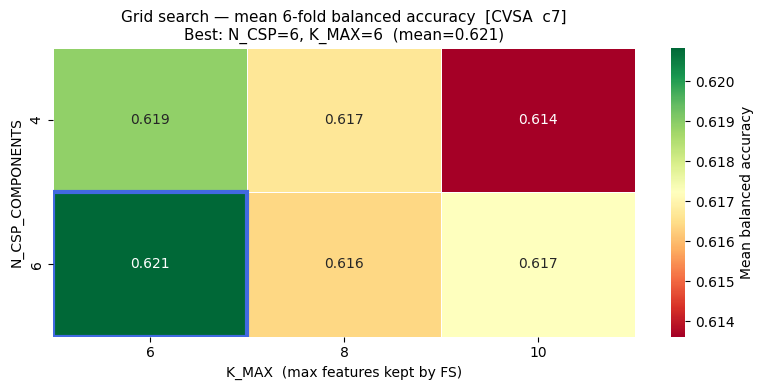

In [20]:
# Grid search: find optimal N_CSP_COMPONENTS and FS_K_TOP_MAX using StratifiedGroupKFold(K=6), with precomputed CSP transforms for speed

LDA_SHRINKAGE = 'auto'
LDA_PRIORS    = [0.5, 0.5]
K_FOLDS       = 6
FS_METHOD     = 'mrmr'
FS_SCORE_FRAC = 0.25
N_CSP_COMPONENTS_GRID = [4, 6]
K_MAX_GRID            = [6, 8, 10]
sgkf = StratifiedGroupKFold(n_splits=K_FOLDS)
fold_splits = list(sgkf.split(X_epochs, y_epochs, groups=trials))
def _csp_fold(n_comp, fold_idx, tr_idx, te_idx, X_ep, y_ep, bands):
    Xtr = np.zeros((len(tr_idx), len(bands), n_comp))
    Xte = np.zeros((len(te_idx), len(bands), n_comp))
    for b in range(len(bands)):
        csp_gs = CSP(n_components=n_comp, reg="ledoit_wolf", log=True,
                     norm_trace=False, component_order="alternate", cov_est="concat")
        csp_gs.fit(X_ep[tr_idx][:, b, :, :], y_ep[tr_idx])
        Xtr[:, b, :] = csp_gs.transform(X_ep[tr_idx][:, b, :, :])
        Xte[:, b, :] = csp_gs.transform(X_ep[te_idx][:, b, :, :])
    return (n_comp, fold_idx,
            flatten_csp(Xtr, len(bands), n_comp),
            flatten_csp(Xte, len(bands), n_comp),
            y_ep[tr_idx], y_ep[te_idx])

X_sel = X_epochs[:, :, SELECTED_INDEX_CH, :]

# n_jobs=2: limita i job paralleli per evitare OOM.
# Ogni thread fa X_ep[tr_idx] (fancy index) = copia di ~1.2 GB;
# con n_jobs=-1 (tutti i core) si esaurisce la RAM.
print("Precomputing CSP transforms (parallel)...")
jobs = [(n_comp, fold_idx, tr_idx, te_idx)
        for n_comp in N_CSP_COMPONENTS_GRID
        for fold_idx, (tr_idx, te_idx) in enumerate(fold_splits)]
raw_results = Parallel(n_jobs=2, prefer="threads")(
    delayed(_csp_fold)(nc, fi, tri, tei,
                       X_sel, y_epochs, BANDS)
    for nc, fi, tri, tei in jobs)
csp_cache = {n: [None] * K_FOLDS for n in N_CSP_COMPONENTS_GRID}
for nc, fi, Xtr_flat, Xte_flat, y_tr, y_te in raw_results:
    csp_cache[nc][fi] = (Xtr_flat, Xte_flat, y_tr, y_te)
print(f"  Done: {len(N_CSP_COMPONENTS_GRID)} n_comp × {K_FOLDS} folds = {len(jobs)} parallel jobs")
grid_results = {}
grid_mean    = {}
valid_combos = []
fold_headers = "  ".join(f"  F{f+1}  " for f in range(K_FOLDS))
print(f"\n{'N_CSP':>5} | {'K_MAX':>5} | {fold_headers} | {'Mean':>6} | {'Std':>5}")
print("─" * (5 + 3 + 5 + 3 + K_FOLDS * 9 + 3 + 8 + 3 + 7))
for n_comp in N_CSP_COMPONENTS_GRID:
    n_feat_max = n_comp * len(BANDS)
    for k_max in K_MAX_GRID:
        if k_max > n_feat_max:
            continue
        fold_accs = []
        for Xtr_log, Xte_log, y_tr, y_te in csp_cache[n_comp]:
            sel_gs, _ = select_features(Xtr_log, y_tr, classes,
                                        FS_METHOD, k_max, FS_SCORE_FRAC)
            clf_gs = LinearDiscriminantAnalysis(
                solver='lsqr', shrinkage=LDA_SHRINKAGE, priors=LDA_PRIORS)
            clf_gs.fit(Xtr_log[:, sel_gs], y_tr)
            acc = balanced_accuracy_score(y_te, clf_gs.predict(Xte_log[:, sel_gs]))
            fold_accs.append(acc)
        mean_a = float(np.mean(fold_accs))
        std_a  = float(np.std(fold_accs))
        grid_results[(n_comp, k_max)] = fold_accs
        grid_mean[(n_comp, k_max)]    = mean_a
        valid_combos.append((n_comp, k_max))
        folds_str = "  ".join(f"{a:.3f}" for a in fold_accs)
        print(f"  {n_comp:>3}  |  {k_max:>3}  | {folds_str}  | {mean_a:.3f}  | {std_a:.3f}")
best_combo       = max(grid_mean, key=grid_mean.get)
N_CSP_COMPONENTS = best_combo[0]
FS_K_TOP_MAX     = best_combo[1]
sep = "─" * 60
print(f"\n{sep}")
print(f"  Best:  N_CSP_COMPONENTS = {N_CSP_COMPONENTS}   FS_K_TOP_MAX = {FS_K_TOP_MAX}")
print(f"  Mean balanced accuracy  : {grid_mean[best_combo]:.3f}")
print(f"  Per-fold accs           : {[f'{a:.3f}' for a in grid_results[best_combo]]}")
print(f"{sep}")
n_comps_valid = sorted(set(c[0] for c in valid_combos))
k_maxs_valid  = sorted(set(c[1] for c in valid_combos))
hm_data = np.full((len(n_comps_valid), len(k_maxs_valid)), np.nan)
for i, nc in enumerate(n_comps_valid):
    for j, km in enumerate(k_maxs_valid):
        if (nc, km) in grid_mean:
            hm_data[i, j] = grid_mean[(nc, km)]
fig, ax = plt.subplots(figsize=(8, 4))
df_hm = pd.DataFrame(hm_data, index=n_comps_valid, columns=k_maxs_valid)
sns.heatmap(df_hm, annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=np.nanmin(hm_data), vmax=np.nanmax(hm_data),
            linewidths=0.5, ax=ax,
            cbar_kws={"label": "Mean balanced accuracy"})
ax.set_xlabel("K_MAX  (max features kept by FS)", fontsize=10)
ax.set_ylabel("N_CSP_COMPONENTS", fontsize=10)
ax.set_title(
    f"Grid search — mean {K_FOLDS}-fold balanced accuracy  "
    f"[{paradigm_to_save.upper()}  {subject}]\n"
    f"Best: N_CSP={N_CSP_COMPONENTS}, K_MAX={FS_K_TOP_MAX}  "
    f"(mean={grid_mean[best_combo]:.3f})",
    fontsize=11)
best_i = n_comps_valid.index(N_CSP_COMPONENTS)
best_j = k_maxs_valid.index(FS_K_TOP_MAX)
ax.add_patch(plt.Rectangle((best_j, best_i), 1, 1,
                            fill=False, edgecolor="royalblue", lw=3))
plt.tight_layout()
plt.show()


--- 6-fold StratifiedGroupKFold ---
  Fold 1: 50 train / 10 test trials | train 0.736  test 0.682  gap +0.054 | FS kept  4 feat: [1, 12, 15, 16]
  Fold 2: 50 train / 10 test trials | train 0.738  test 0.598  gap +0.140 | FS kept  6 feat: [1, 9, 12, 13, 14, 17]
  Fold 3: 50 train / 10 test trials | train 0.728  test 0.668  gap +0.059 | FS kept  6 feat: [1, 2, 12, 14, 16, 17]
  Fold 4: 50 train / 10 test trials | train 0.713  test 0.525  gap +0.188 | FS kept  4 feat: [1, 3, 12, 14]
  Fold 5: 50 train / 10 test trials | train 0.731  test 0.545  gap +0.186 | FS kept  3 feat: [7, 12, 14]
  Fold 6: 50 train / 10 test trials | train 0.720  test 0.707  gap +0.014 | FS kept  6 feat: [3, 7, 12, 14, 15, 16]

────────────────────────────────────────────────────────
  CV  |  K=6  shrinkage='auto'  priors=[0.5, 0.5]
  Features : ~4 kept (per-fold avg) / 18 total  (3 bands × 6 components, FS=mrmr, max=6, frac=0.25)  |  ratio : 7.5x
────────────────────────────────────────────────────────
  Balanced a

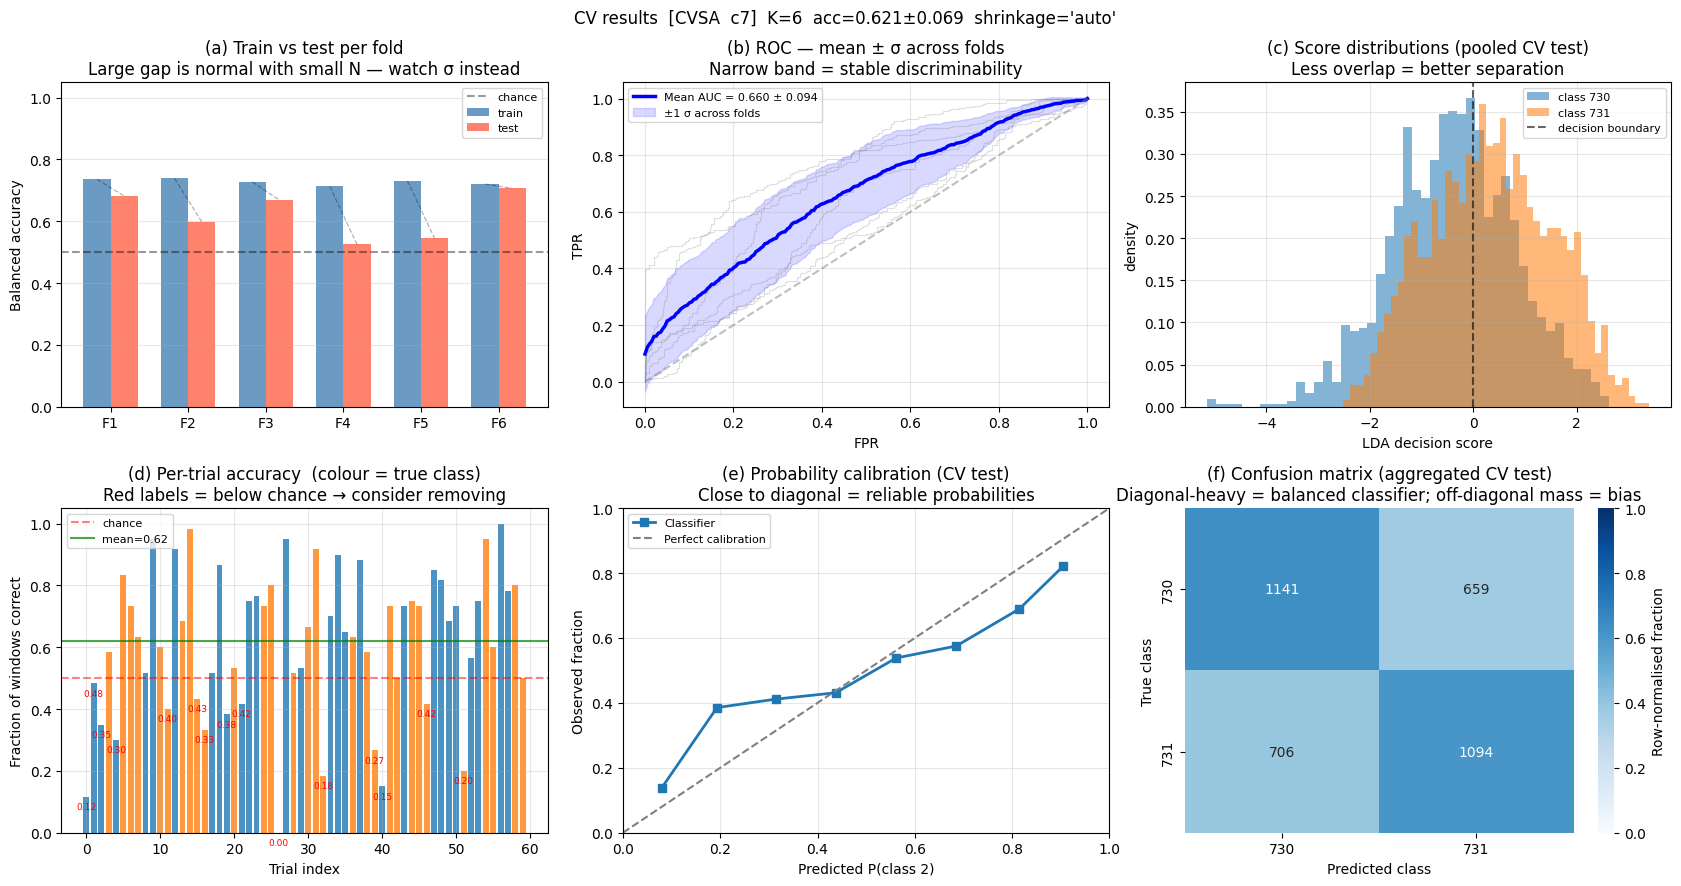

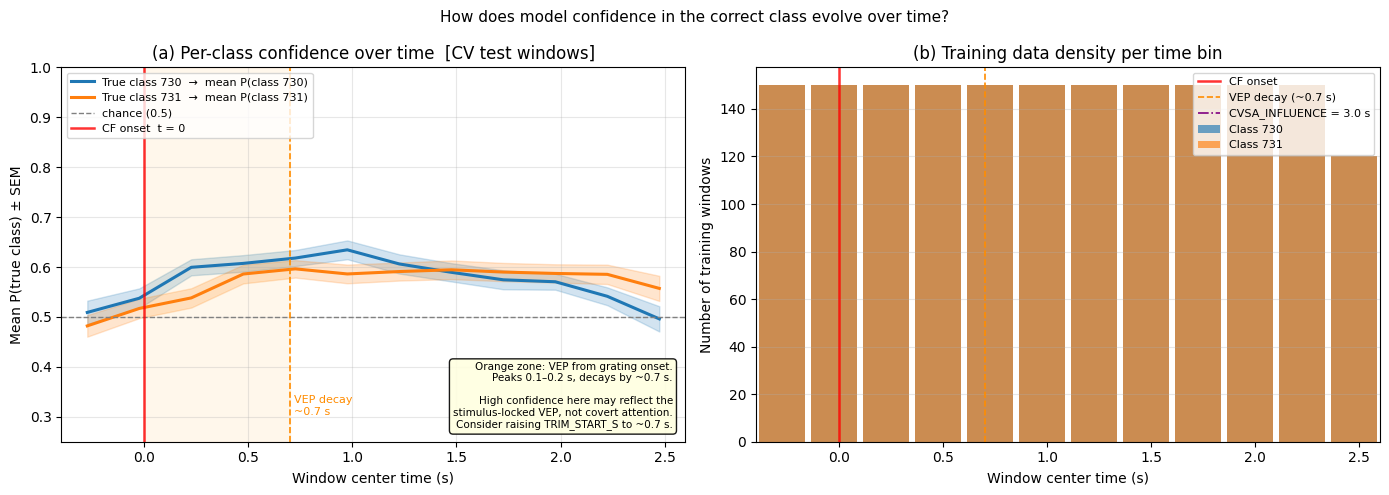

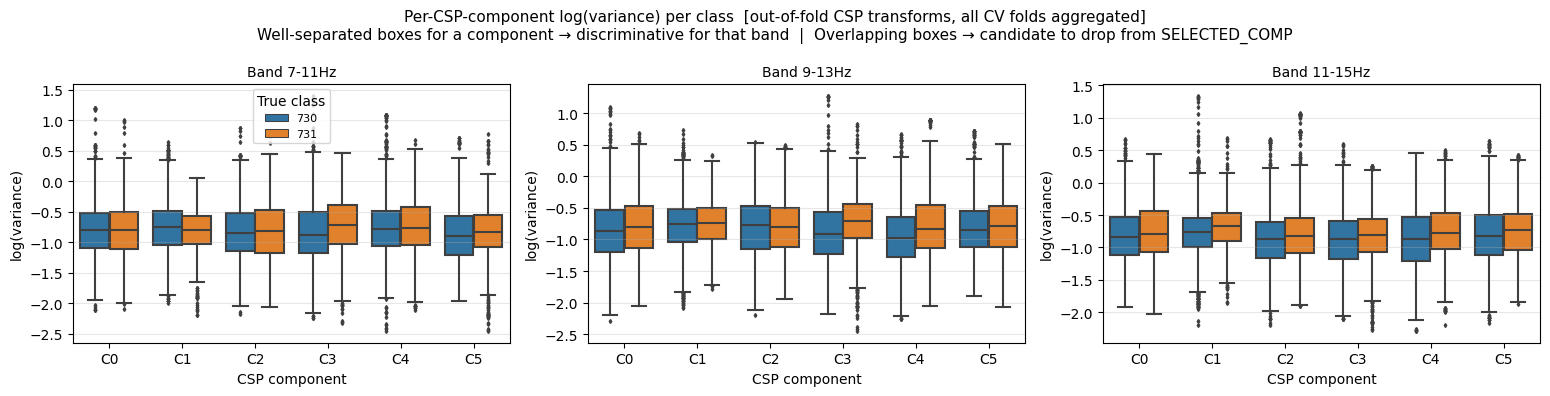

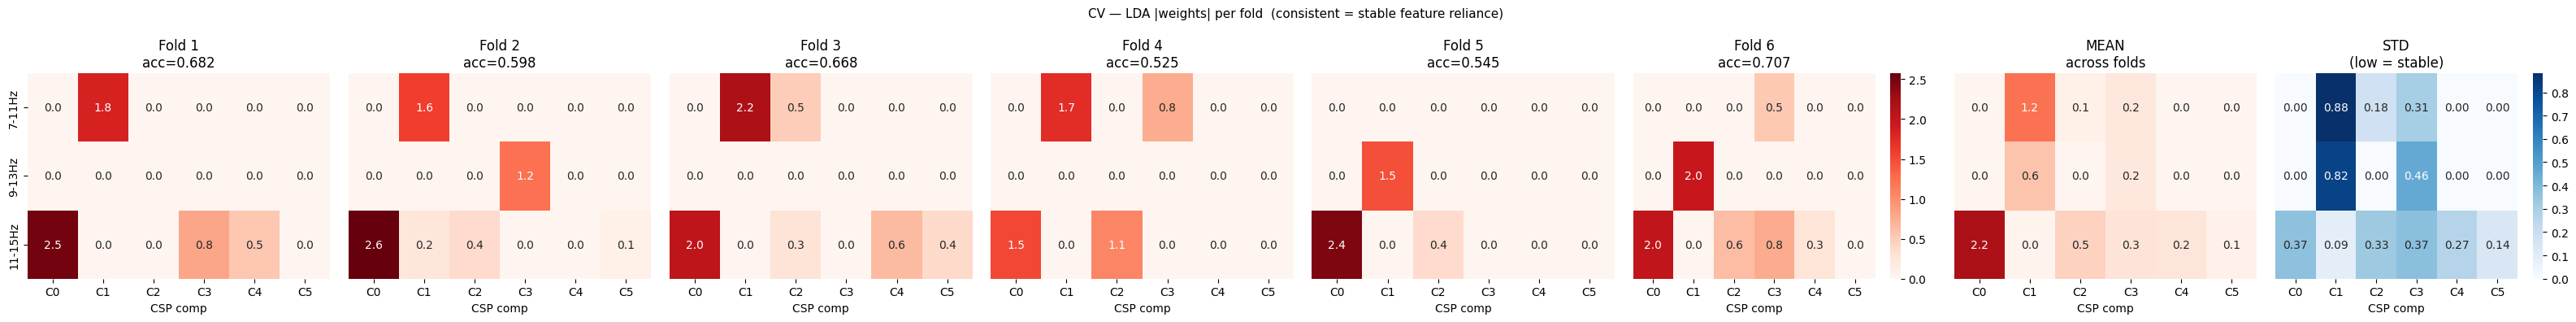

In [21]:
# Diagnostic cross-validation: full CV with grid-search parameters — ROC, calibration, per-trial accuracy, and LDA weight plots

SELECTED_COMP = list(range(N_CSP_COMPONENTS))
selected_indices = SELECTED_COMP
n_sel = len(SELECTED_COMP)
all_X_csp_oof = np.zeros((len(X_epochs), len(BANDS), N_CSP_COMPONENTS))
sgkf = StratifiedGroupKFold(n_splits=K_FOLDS)
fold_clfs, fold_train_accs, fold_test_accs = [], [], []
fold_cms, fold_fpr_list, fold_tpr_list = [], [], []
fold_selections = []
fold_X_tr_log  = []
fold_y_tr      = []
all_y_true, all_y_pred, all_scores, all_trials_cv, all_t_centers = [], [], [], [], []
print(f"--- {K_FOLDS}-fold StratifiedGroupKFold ---")
for fold_idx, (tr_idx, te_idx) in enumerate(
        sgkf.split(X_epochs, y_epochs, groups=trials), 1):
    X_tr_csp = np.zeros((len(tr_idx), len(BANDS), N_CSP_COMPONENTS))
    X_te_csp = np.zeros((len(te_idx), len(BANDS), N_CSP_COMPONENTS))
    for b in range(len(BANDS)):
        csp_f = CSP(n_components=N_CSP_COMPONENTS, reg='ledoit_wolf', log=True,
                    norm_trace=False, component_order='alternate', 
                    cov_est='concat')
        csp_f.fit(X_epochs[tr_idx][:, b, SELECTED_INDEX_CH, :], y_epochs[tr_idx])
        X_tr_csp[:, b, :] = csp_f.transform(X_epochs[tr_idx][:, b, SELECTED_INDEX_CH, :])
        X_te_csp[:, b, :] = csp_f.transform(X_epochs[te_idx][:, b, SELECTED_INDEX_CH, :])
    all_X_csp_oof[te_idx] = X_te_csp
    X_tr = flatten_csp(X_tr_csp[:, :, SELECTED_COMP], len(BANDS), n_sel)
    X_te = flatten_csp(X_te_csp[:, :, SELECTED_COMP], len(BANDS), n_sel)
    y_tr, y_te = y_epochs[tr_idx], y_epochs[te_idx]
    sel_fold, _ = select_features(X_tr, y_tr, classes, FS_METHOD,
                                  FS_K_TOP_MAX, FS_SCORE_FRAC)
    fold_X_tr_log.append(X_tr)
    X_tr = X_tr[:, sel_fold]
    X_te = X_te[:, sel_fold]
    fold_y_tr.append(y_tr)
    clf = LinearDiscriminantAnalysis(solver='lsqr', shrinkage=LDA_SHRINKAGE, priors=LDA_PRIORS)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    scores = clf.decision_function(X_te)
    acc_tr = balanced_accuracy_score(y_tr, clf.predict(X_tr))
    acc_te = balanced_accuracy_score(y_te, y_pred)
    fold_train_accs.append(acc_tr); fold_test_accs.append(acc_te)
    fold_cms.append(confusion_matrix(y_te, y_pred, labels=classes))
    fold_clfs.append(clf); fold_selections.append(sel_fold)
    fpr_f, tpr_f, _ = roc_curve((y_te == classes[1]).astype(int), scores)
    fold_fpr_list.append(fpr_f); fold_tpr_list.append(tpr_f)
    all_y_true.append(y_te);  all_y_pred.append(y_pred)
    all_scores.append(scores); all_trials_cv.append(trials[te_idx])
    all_t_centers.append(t_centers[te_idx])
    print(f"  Fold {fold_idx}: {len(np.unique(trials[tr_idx])):2d} train / "
          f"{len(np.unique(trials[te_idx])):2d} test trials | "
          f"train {acc_tr:.3f}  test {acc_te:.3f}  gap {acc_tr-acc_te:+.3f} "
          f"| FS kept {len(sel_fold):2d} feat: {sorted(int(i) for i in sel_fold)}")
all_y_true    = np.concatenate(all_y_true)
all_y_pred    = np.concatenate(all_y_pred)
all_scores    = np.concatenate(all_scores)
all_trials_cv = np.concatenate(all_trials_cv)
all_t_centers = np.concatenate(all_t_centers)
mean_acc = float(np.mean(fold_test_accs))
std_acc  = float(np.std(fold_test_accs))
mean_cm  = np.sum(fold_cms, axis=0)
mean_gap = float(np.mean(np.array(fold_train_accs) - np.array(fold_test_accs)))
prob_class1 = 1 / (1 + np.exp(-all_scores))
prob_correct = np.where(all_y_true == classes[1], prob_class1, 1 - prob_class1)
n_features_total = len(BANDS) * n_sel
n_features       = int(np.mean([len(s) for s in fold_selections])) if FS_METHOD else n_features_total
ratio            = (len(np.unique(trials)) // 2) / max(n_features, 1)
sep     = "─" * 56
quality = "GOOD" if mean_acc >= 0.75 else ("MARGINAL" if mean_acc >= 0.65 else "WEAK")
std_ok  = std_acc < 0.08
rat_ok  = ratio   >= 5
print(f"\n{sep}")
print(f"  CV  |  K={K_FOLDS}  shrinkage={LDA_SHRINKAGE!r}  priors={LDA_PRIORS}")
print(f"  Features : ~{n_features} kept (per-fold avg) / {n_features_total} total  ({len(BANDS)} bands × {n_sel} components, FS={FS_METHOD}, max={FS_K_TOP_MAX}, frac={FS_SCORE_FRAC})  |  ratio : {ratio:.1f}x")
print(f"{sep}")
print(f"  Balanced accuracy   : {mean_acc:.3f} +/- {std_acc:.3f}  [{quality}]")
print(f"  Fold variance sigma : {std_acc:.3f}  [{'stable' if std_ok else 'UNSTABLE — reduce features'}]")
print(f"  Train-test gap      : {mean_gap:+.3f}  [expected with small N — watch sigma, not gap]")
print(f"{sep}")
if not rat_ok:
    thr = "< 3 — high overfit risk" if ratio < 3 else "< 5 — borderline, Ledoit-Wolf essential"
    print(f"  ! ratio {thr}: reduce bands or components")
if not std_ok:
    print("  ! High fold sigma (> 8%) — model may be struggling to generalize. Recommendation: reduce N_CSP_COMPONENTS to 2 to halve feature size and check per-trial panel for outliers.")
if mean_acc < 0.65:
    print("  ! Weak signal — verify SELECTED_CHANNELS and BANDS for this paradigm")
print(f"{sep}\n")
auc_scores = [auc(f, t) for f, t in zip(fold_fpr_list, fold_tpr_list)]
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle(
    f"CV results  [{paradigm_to_save.upper()}  {subject}]  "
    f"K={K_FOLDS}  acc={mean_acc:.3f}±{std_acc:.3f}  shrinkage={LDA_SHRINKAGE!r}",
    fontsize=12)
ax = axes[0, 0]
x = np.arange(K_FOLDS); w = 0.35
ax.bar(x - w/2, fold_train_accs, w, label='train', color='steelblue', alpha=0.8)
ax.bar(x + w/2, fold_test_accs,  w, label='test',  color='tomato',    alpha=0.8)
ax.axhline(0.5, color='k', linestyle='--', alpha=0.4, label='chance')
for xi, (tr, te) in enumerate(zip(fold_train_accs, fold_test_accs)):
    ax.plot([xi - w/2, xi + w/2], [tr, te], 'k--', alpha=0.3, lw=0.9)
ax.set_xticks(x); ax.set_xticklabels([f'F{i+1}' for i in x])
ax.set(ylabel='Balanced accuracy', ylim=[0, 1.05],
       title='(a) Train vs test per fold\nLarge gap is normal with small N — watch σ instead')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
ax = axes[0, 1]
mean_fpr    = np.linspace(0, 1, 200)
tprs_interp = [np.interp(mean_fpr, f, t) for f, t in zip(fold_fpr_list, fold_tpr_list)]
mean_tpr    = np.mean(tprs_interp, axis=0)
std_tpr     = np.std(tprs_interp, axis=0)
for fpr_f, tpr_f in zip(fold_fpr_list, fold_tpr_list):
    ax.plot(fpr_f, tpr_f, color='gray', alpha=0.25, lw=0.8)
ax.plot(mean_fpr, mean_tpr, 'b', lw=2.5,
        label=f'Mean AUC = {np.mean(auc_scores):.3f} ± {np.std(auc_scores):.3f}')
ax.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                alpha=0.15, color='b', label='±1 σ across folds')
ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
ax.set(xlabel='FPR', ylabel='TPR',
       title='(b) ROC — mean ± σ across folds\nNarrow band = stable discriminability')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[0, 2]
for i, cls in enumerate(classes):
    ax.hist(all_scores[all_y_true == cls], bins=45, alpha=0.55,
            density=True, label=f'class {cls}', color=f'C{i}')
ax.axvline(0, color='k', linestyle='--', alpha=0.6, label='decision boundary')
ax.set(xlabel='LDA decision score', ylabel='density',
       title='(c) Score distributions (pooled CV test)\nLess overlap = better separation')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1, 0]
unique_t = np.unique(all_trials_cv)
t_accs, t_cls = [], []
for t in unique_t:
    m = all_trials_cv == t
    t_accs.append(np.mean(all_y_true[m] == all_y_pred[m]))
    t_cls.append(all_y_true[m][0])
ax.bar(unique_t, t_accs, color=['C0' if c == classes[0] else 'C1' for c in t_cls], alpha=0.8)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='chance')
ax.axhline(np.mean(t_accs), color='green', alpha=0.7, label=f'mean={np.mean(t_accs):.2f}')
for t, acc in zip(unique_t, t_accs):
    if acc < 0.5:
        ax.text(t, acc - 0.04, f'{acc:.2f}', ha='center', fontsize=6.5, color='red')
ax.set(xlabel='Trial index', ylabel='Fraction of windows correct',
       title='(d) Per-trial accuracy  (colour = true class)\nRed labels = below chance → consider removing')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1, 1]
frac_pos, mean_pred = calibration_curve(
    (all_y_true == classes[1]).astype(int), prob_class1, n_bins=8, strategy='uniform')
ax.plot(mean_pred, frac_pos, 's-', lw=2, label='Classifier')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
ax.set(xlabel='Predicted P(class 2)', ylabel='Observed fraction',
       title='(e) Probability calibration (CV test)\nClose to diagonal = reliable probabilities',
       xlim=[0, 1], ylim=[0, 1])
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1, 2]
cm_norm = mean_cm / mean_cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=mean_cm.astype(int), fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax, vmin=0, vmax=1,
            cbar_kws={'label': 'Row-normalised fraction'})
ax.set(xlabel='Predicted class', ylabel='True class',
       title='(f) Confusion matrix (aggregated CV test)\n'
             'Diagonal-heavy = balanced classifier; off-diagonal mass = bias')
plt.tight_layout(); plt.show()
BINS_S = np.arange(round(all_t_centers.min(), 1),
                   round(all_t_centers.max(), 1) + 0.25, 0.25)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "How does model confidence in the correct class evolve over time?",
    fontsize=11)
ax = axes[0]
for c_i, cls in enumerate(classes):
    mask = all_y_true == cls
    df_c = pd.DataFrame({'t': all_t_centers[mask], 'p': prob_correct[mask]})
    df_c['bin'] = pd.cut(df_c['t'], bins=BINS_S)
    grp    = df_c.groupby('bin', observed=True)['p']
    b_mean = grp.mean()
    b_sem  = grp.std() / np.sqrt(grp.count())
    t_mid  = np.array([b.mid for b in b_mean.index])
    ax.plot(t_mid, b_mean.values, color=f'C{c_i}', lw=2.2,
            label=f'True class {cls}  →  mean P(class {cls})')
    ax.fill_between(t_mid,
                    b_mean.values - b_sem.values,
                    b_mean.values + b_sem.values,
                    alpha=0.2, color=f'C{c_i}')
ax.axhline(0.5, color='gray', linestyle='--', lw=1, label='chance (0.5)')
ax.axvline(0.0, color='red',  lw=1.8, alpha=0.8, label='CF onset  t = 0')
if paradigm_to_save == 'mi':
    ax.axvspan(all_t_centers.min(), 0.3, alpha=0.07, color='gray')
    ax.axvline(0.3, color='k', lw=1.2, linestyle='--')
    ax.text(0.30, 0.30, ' ERD onset\n  ~0.3 s', fontsize=8, color='k', va='bottom')
    note = ("Grey zone: ring buffer still contains pre-CF\n"
            "cue activity + early CF transient.\n"
            "Genuine motor ERD builds after ~0.3 s.\n\n"
            "Ideal: P(true class) rises after grey zone\n"
            "and stays clearly above 0.5.")
elif paradigm_to_save == 'cvsa':
    ax.axvspan(0, 0.7, alpha=0.08, color='orange')
    ax.axvline(0.7, color='darkorange', lw=1.2, linestyle='--')
    ax.text(0.72, 0.30, 'VEP decay\n~0.7 s', fontsize=8, color='darkorange', va='bottom')
    note = ("Orange zone: VEP from grating onset.\n"
            "Peaks 0.1–0.2 s, decays by ~0.7 s.\n\n"
            "High confidence here may reflect the\n"
            "stimulus-locked VEP, not covert attention.\n"
            "Consider raising TRIM_START_S to ~0.7 s.")
else:
    note = ""
if note:
    ax.text(0.98, 0.03, note, transform=ax.transAxes,
            fontsize=7.5, va='bottom', ha='right',
            bbox=dict(boxstyle='round,pad=0.35', fc='lightyellow', alpha=0.9))
ax.set(xlabel='Window center time (s)',
       ylabel='Mean P(true class) ± SEM',
       xlim=[BINS_S[0], BINS_S[-1]], ylim=[0.25, 1.0],
       title='(a) Per-class confidence over time  [CV test windows]')
ax.legend(fontsize=8, loc='upper left'); ax.grid(alpha=0.3)
ax = axes[1]
for c_i, cls in enumerate(classes):
    mask = all_y_true == cls
    counts, edges = np.histogram(all_t_centers[mask], bins=BINS_S)
    mid = (edges[:-1] + edges[1:]) / 2
    ax.bar(mid, counts, width=0.22, alpha=0.65, color=f'C{c_i}',
           label=f'Class {cls}', align='center')
ax.axvline(0.0, color='red', lw=1.8, alpha=0.8, label='CF onset')
if paradigm_to_save == 'mi':
    ax.axvline(0.3, color='k', lw=1.2, linestyle='--', label='ERD onset (~0.3 s)')
elif paradigm_to_save == 'cvsa':
    ax.axvline(0.7, color='darkorange', lw=1.2, linestyle='--', label='VEP decay (~0.7 s)')
    if CVSA_INFLUENCE is not None:
        ax.axvline(CVSA_INFLUENCE, color='purple', lw=1.2, linestyle='-.',
                   label=f'CVSA_INFLUENCE = {CVSA_INFLUENCE} s')
ax.set(xlabel='Window center time (s)',
       ylabel='Number of training windows',
       xlim=[BINS_S[0], BINS_S[-1]],
       title='(b) Training data density per time bin')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()
n_bands_plot = len(BANDS)
nrows = int(np.ceil(n_bands_plot / 3))
ncols = min(3, n_bands_plot)
fig, axes_grid = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4 * nrows), squeeze=False)
axes_flat = axes_grid.flatten()
palette = {classes[0]: 'C0', classes[1]: 'C1'}
for b in range(n_bands_plot):
    ax = axes_flat[b]
    data_b = all_X_csp_oof[:, b, :]
    df_b = pd.DataFrame(data_b, columns=[f'C{c}' for c in range(N_CSP_COMPONENTS)])
    df_b['class'] = all_y_true
    df_long = df_b.melt(id_vars='class', var_name='Component', value_name='log(variance)')
    sns.boxplot(data=df_long, x='Component', y='log(variance)', hue='class',
                palette=palette, ax=ax, fliersize=2)
    ax.set_title(f'Band {BANDS_STR[b]}', fontsize=10)
    ax.set_xlabel('CSP component')
    ax.grid(alpha=0.3, axis='y')
    if b > 0:
        ax.get_legend().remove()
    else:
        ax.legend(title='True class', fontsize=8)
for i in range(n_bands_plot, len(axes_flat)):
    axes_flat[i].set_visible(False)
fig.suptitle("Per-CSP-component log(variance) per class  "
             "[out-of-fold CSP transforms, all CV folds aggregated]\n"
             "Well-separated boxes for a component → discriminative for that band  |  "
             "Overlapping boxes → candidate to drop from SELECTED_COMP",
             fontsize=11)
plt.tight_layout()
plt.show()
fold_weights = np.zeros((K_FOLDS, len(BANDS), n_sel))
for _k, (_c, _sel) in enumerate(zip(fold_clfs, fold_selections)):
    _flat = np.zeros(len(BANDS) * n_sel)
    _flat[np.asarray(_sel, dtype=int)] = _c.coef_[0]
    fold_weights[_k] = _flat.reshape(len(BANDS), n_sel)
fig, axes = plt.subplots(1, K_FOLDS + 2, figsize=(4 * (K_FOLDS + 2), 4))
fig.suptitle("CV — LDA |weights| per fold  (consistent = stable feature reliance)", fontsize=11)
vmax = np.abs(fold_weights).max()
for i in range(K_FOLDS):
    sns.heatmap(np.abs(fold_weights[i]), annot=True, fmt='.1f', cmap='Reds',
                vmin=0, vmax=vmax,
                xticklabels=[f'C{j}' for j in SELECTED_COMP],
                yticklabels=BANDS_STR if i == 0 else [],
                cbar=(i == K_FOLDS - 1), ax=axes[i])
    axes[i].set_title(f'Fold {i+1}\nacc={fold_test_accs[i]:.3f}')
    axes[i].set_xlabel('CSP comp')
sns.heatmap(np.abs(fold_weights).mean(0), annot=True, fmt='.1f', cmap='Reds',
            vmin=0, vmax=vmax,
            xticklabels=[f'C{j}' for j in SELECTED_COMP], yticklabels=[], cbar=False,
            ax=axes[K_FOLDS])
axes[K_FOLDS].set_title('MEAN\nacross folds'); axes[K_FOLDS].set_xlabel('CSP comp')
sns.heatmap(np.abs(fold_weights).std(0), annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f'C{j}' for j in SELECTED_COMP], yticklabels=[], cbar=True,
            ax=axes[K_FOLDS + 1])
axes[K_FOLDS + 1].set_title('STD\n(low = stable)'); axes[K_FOLDS + 1].set_xlabel('CSP comp')
plt.tight_layout(); plt.show()


CSP: 3 bands × 6 components | Feature matrix: (3600, 18)  [band-major]

────────────────────────────────────────────────────────────────────────────
  CV-aggregated feature selection  (method=mrmr, K=6-fold voting)
────────────────────────────────────────────────────────────────────────────
  Total candidates : 18  (3 bands × 6 components)
  Majority vote    : feature must be picked in >= 3/6 folds
  Hard cap (max)   : 6
  Soft cap (frac)  : 0.25  (drop if relevance < frac × top)
  Kept             : 4

  Rank | idx | band       | CSP comp | folds picked | mean MI/score
  -----+-----+------------+----------+--------------+--------------
     1 |  12 | 11-15Hz    | C0       |    6/6       | 0.0995
     2 |  14 | 11-15Hz    | C2       |    5/6       | 0.0592
     3 |   1 | 7-11Hz     | C1       |    4/6       | 0.0582
     4 |  16 | 11-15Hz    | C4       |    3/6       | 0.0313
────────────────────────────────────────────────────────────────────────────
  Below majority (NOT kept):
     

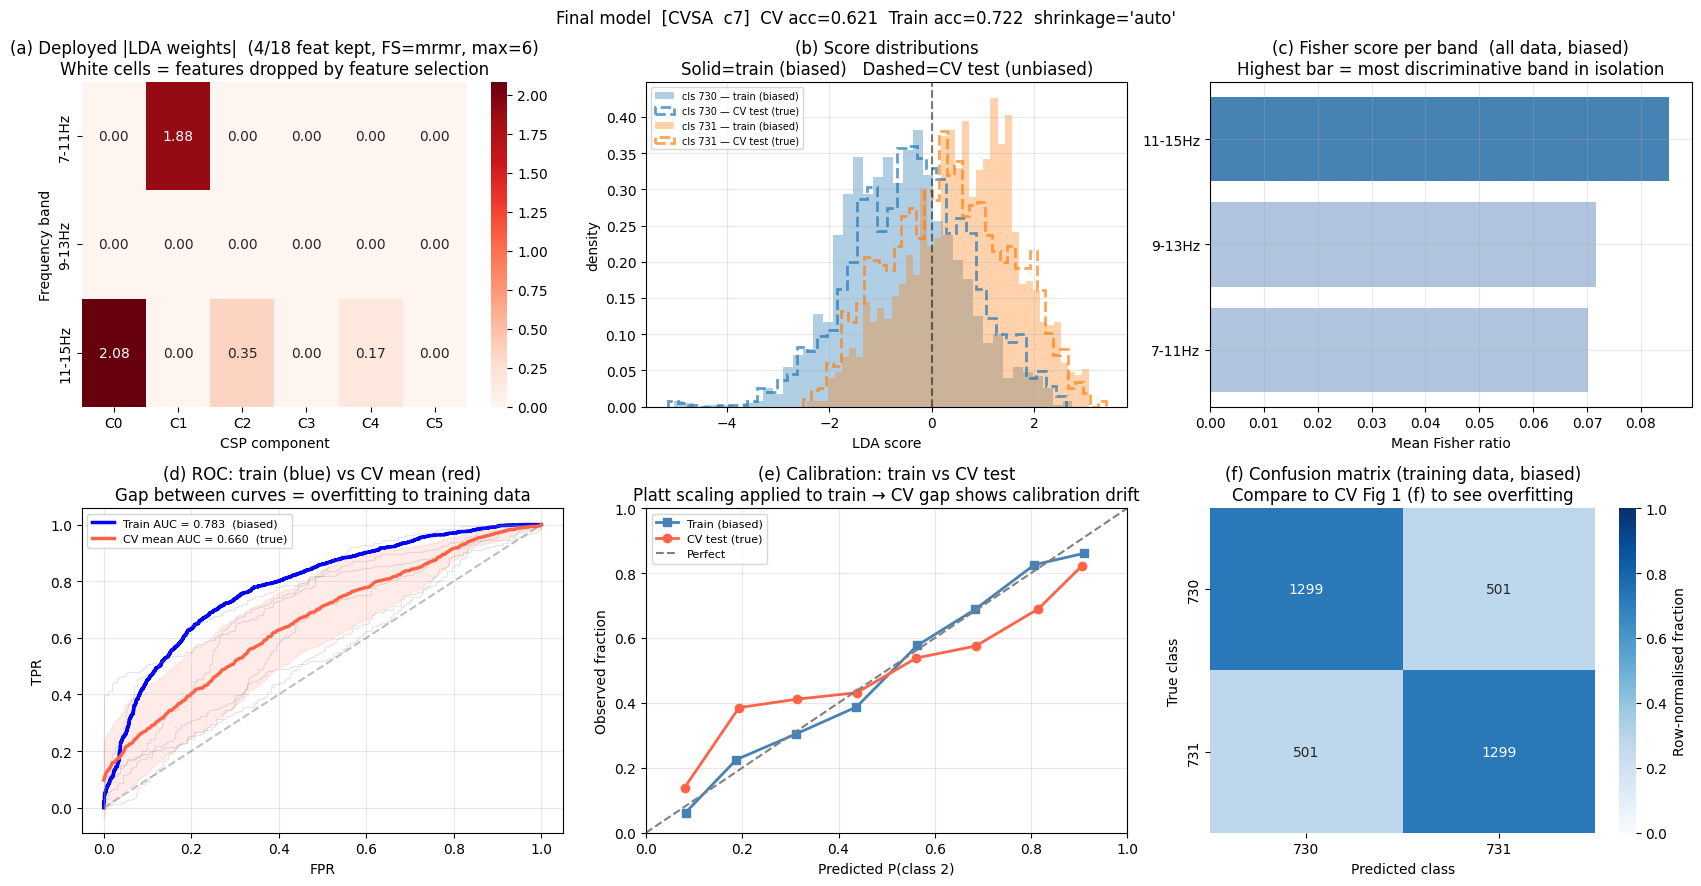

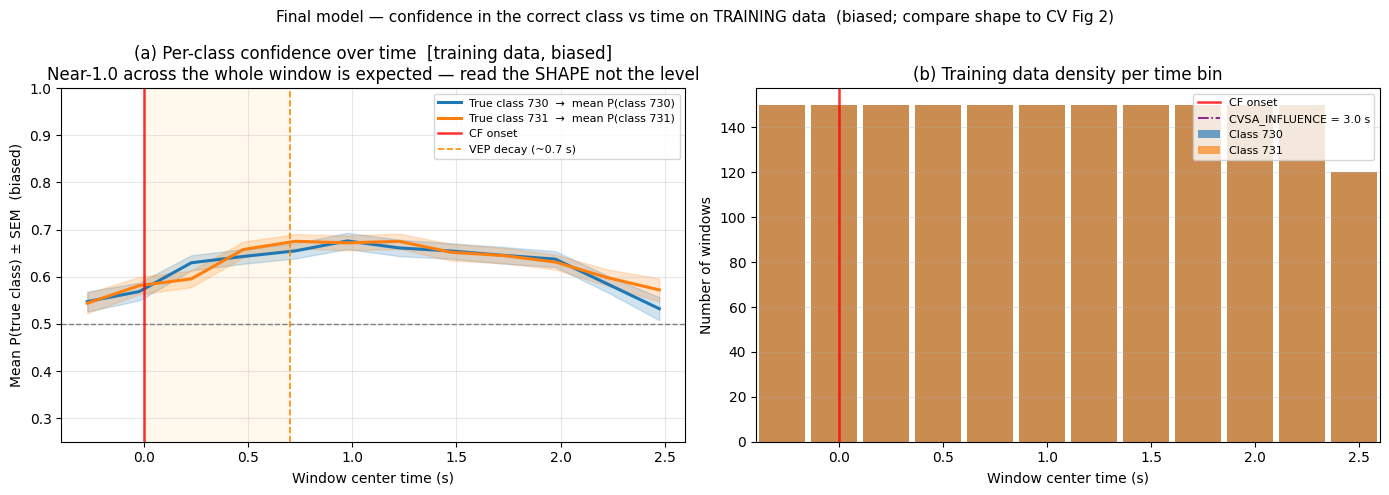

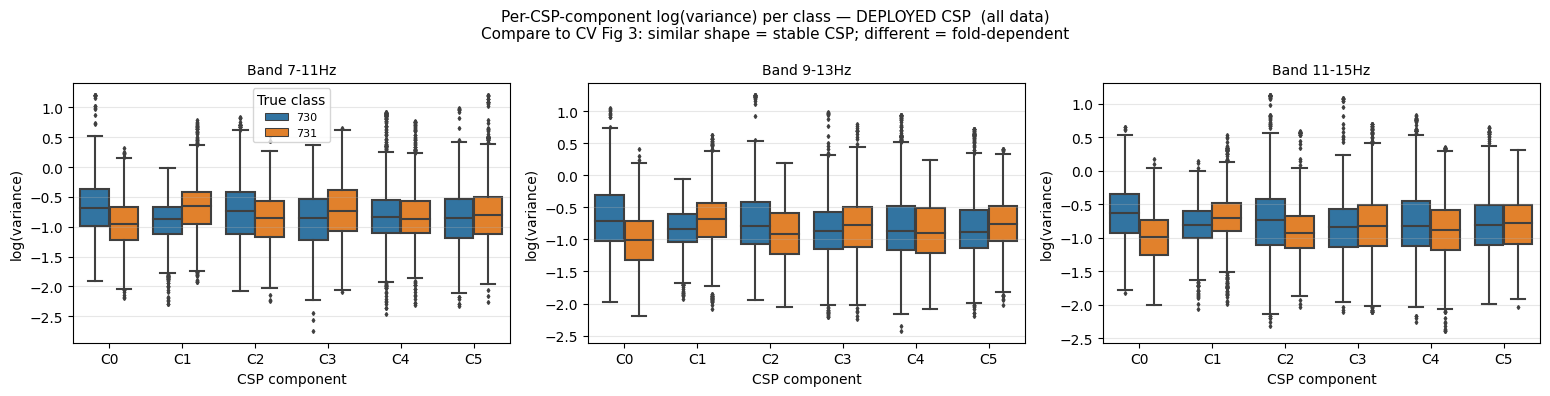

In [22]:
# All-data model: fit CSP on all epochs, then CV-aggregated feature selection to produce the deployed feature index set

csp_list  = [CSP(n_components=N_CSP_COMPONENTS, reg='ledoit_wolf', log=True,
                 norm_trace=False, component_order='alternate', cov_est='concat')
             for _ in range(len(BANDS))]
X_csp_all = np.zeros((len(X_epochs), len(BANDS), N_CSP_COMPONENTS))
for b in range(len(BANDS)):
    X_b = X_epochs[:, b, SELECTED_INDEX_CH, :]
    csp_list[b].fit(X_b, y_epochs)
    X_csp_all[:, b, :] = csp_list[b].transform(X_b)
X_csp_sel  = X_csp_all[:, :, SELECTED_COMP]
X_features = flatten_csp(X_csp_sel, len(BANDS), n_sel)
print(f"CSP: {len(BANDS)} bands × {N_CSP_COMPONENTS} components | "
      f"Feature matrix: {X_features.shape}  [band-major]")
selected_picks_ordered, mean_relevance, pick_count, fold_picks_all = cv_aggregate_select(
    fold_X_tr_log, fold_y_tr, classes,
    FS_METHOD, FS_K_TOP_MAX, FS_SCORE_FRAC)
selected_feature_indices = np.sort(selected_picks_ordered)
X_features_sel = X_features[:, selected_feature_indices]
majority = (K_FOLDS + 1) // 2
sep_fs = "─" * 76
print(f"\n{sep_fs}")
print(f"  CV-aggregated feature selection  (method={FS_METHOD}, K={K_FOLDS}-fold voting)")
print(f"{sep_fs}")
print(f"  Total candidates : {X_features.shape[1]}  ({len(BANDS)} bands × {n_sel} components)")
print(f"  Majority vote    : feature must be picked in >= {majority}/{K_FOLDS} folds")
print(f"  Hard cap (max)   : {FS_K_TOP_MAX}")
print(f"  Soft cap (frac)  : {FS_SCORE_FRAC}  (drop if relevance < frac × top)")
print(f"  Kept             : {len(selected_feature_indices)}")
print()
print("  Rank | idx | band       | CSP comp | folds picked | mean MI/score")
print("  -----+-----+------------+----------+--------------+--------------")
for rank, idx in enumerate(selected_picks_ordered, 1):
    idx = int(idx)
    band_id, comp_id = divmod(idx, n_sel)
    score = mean_relevance[idx] if mean_relevance is not None else float('nan')
    print(f"   {rank:>3} | {idx:>3} | {BANDS_STR[band_id]:<10s} | C{SELECTED_COMP[comp_id]:<7d} "
          f"|   {pick_count[idx]:>2d}/{K_FOLDS:<2d}      | {score:.4f}")
print(f"{sep_fs}")
unstable = [i for i in range(X_features.shape[1])
            if 0 < pick_count[i] < majority and i not in selected_feature_indices]
if unstable:
    unstable.sort(key=lambda i: (-pick_count[i],
                                  -(mean_relevance[i] if mean_relevance is not None else 0)))
    print("  Below majority (NOT kept):")
    for idx in unstable[:8]:
        band_id, comp_id = divmod(idx, n_sel)
        score = mean_relevance[idx] if mean_relevance is not None else float('nan')
        print(f"        idx={idx:>2d}  {BANDS_STR[band_id]:<10s} C{SELECTED_COMP[comp_id]}  "
              f"folds={pick_count[idx]}/{K_FOLDS}  score={score:.4f}")
print(f"{sep_fs}\n")
clf_final = LinearDiscriminantAnalysis(solver='lsqr', shrinkage=LDA_SHRINKAGE, priors=LDA_PRIORS)
clf_final.fit(X_features_sel, y_epochs)
y_bin = (all_y_true == classes[1]).astype(int)
sigmoid_calibrator = LogisticRegression(penalty=None)
sigmoid_calibrator.fit(all_scores.reshape(-1, 1), y_bin)
platt_a = float(sigmoid_calibrator.coef_[0][0])
platt_b = float(sigmoid_calibrator.intercept_[0])
print(f"[INFO] Platt sigmoid calibrata su CV: a={platt_a:.3f}  b={platt_b:.3f}")
scores_final    = clf_final.decision_function(X_features_sel)
y_pred_final    = clf_final.predict(X_features_sel)
final_train_acc = balanced_accuracy_score(y_epochs, y_pred_final)
cms_final       = confusion_matrix(y_epochs, y_pred_final, labels=classes)
prob_class1_tr = 1 / (1 + np.exp(-scores_final))
prob_correct_tr = np.where(y_epochs == classes[1], prob_class1_tr, 1 - prob_class1_tr)
sep = "─" * 56
print(f"\n{sep}")
print(f"  FINAL MODEL  ({len(X_epochs)} windows / {len(np.unique(trials))} trials)")
print(f"{sep}")
print(f"  CV accuracy (true generalisation)  : {mean_acc:.3f} ± {std_acc:.3f}")
print(f"  Train accuracy (biased — expected) : {final_train_acc:.3f}")
if platt_a is not None:
    print(f"  Platt sigmoid: a={platt_a:.3f}  b={platt_b:.3f}")
print(f"{sep}\n")
fpr_tr, tpr_tr, _ = roc_curve((y_epochs == classes[1]).astype(int), scores_final)
auc_tr  = auc(fpr_tr, tpr_tr)
prob_tr = prob_class1_tr
prob_cv = 1 / (1 + np.exp(-all_scores))
mean_fpr_cv = np.linspace(0, 1, 200)
tprs_cv_i   = [np.interp(mean_fpr_cv, f, t) for f, t in zip(fold_fpr_list, fold_tpr_list)]
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle(
    f"Final model  [{paradigm_to_save.upper()}  {subject}]  "
    f"CV acc={mean_acc:.3f}  Train acc={final_train_acc:.3f}  "
    f"shrinkage={LDA_SHRINKAGE!r}",
    fontsize=12)
ax = axes[0, 0]
weight_grid = np.zeros(len(BANDS) * n_sel)
weight_grid[selected_feature_indices] = np.abs(clf_final.coef_[0])
weight_grid = weight_grid.reshape(len(BANDS), n_sel)
sns.heatmap(weight_grid, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=[f'C{j}' for j in SELECTED_COMP],
            yticklabels=BANDS_STR, ax=ax)
ax.set(xlabel='CSP component', ylabel='Frequency band',
       title=f'(a) Deployed |LDA weights|  ({len(selected_feature_indices)}/{len(BANDS)*n_sel} feat kept, FS={FS_METHOD}, max={FS_K_TOP_MAX})\nWhite cells = features dropped by feature selection')
ax = axes[0, 1]
for i, cls in enumerate(classes):
    ax.hist(scores_final[y_epochs == cls], bins=40, alpha=0.35, density=True,
            color=f'C{i}', label=f'cls {cls} — train (biased)')
    ax.hist(all_scores[all_y_true == cls], bins=40, alpha=0.7, density=True,
            color=f'C{i}', histtype='step', lw=2, linestyle='--',
            label=f'cls {cls} — CV test (true)')
ax.axvline(0, color='k', linestyle='--', alpha=0.5)
ax.set(xlabel='LDA score', ylabel='density',
       title='(b) Score distributions\nSolid=train (biased)   Dashed=CV test (unbiased)')
ax.legend(fontsize=7); ax.grid(alpha=0.3)
ax = axes[0, 2]
fisher_per_band = [np.mean(get_fisher_score(
    X_features[:, b * n_sel:(b + 1) * n_sel], y_epochs, classes))
    for b in range(len(BANDS))]
colors_f = ['steelblue' if f == max(fisher_per_band) else 'lightsteelblue'
            for f in fisher_per_band]
ax.barh(range(len(BANDS)), fisher_per_band, color=colors_f)
ax.set_yticks(range(len(BANDS))); ax.set_yticklabels(BANDS_STR)
ax.set(xlabel='Mean Fisher ratio',
       title='(c) Fisher score per band  (all data, biased)\n'
             'Highest bar = most discriminative band in isolation')
ax.grid(alpha=0.3)
ax = axes[1, 0]
ax.plot(fpr_tr, tpr_tr, 'b', lw=2.5, label=f'Train AUC = {auc_tr:.3f}  (biased)')
for fpr_f, tpr_f in zip(fold_fpr_list, fold_tpr_list):
    ax.plot(fpr_f, tpr_f, color='gray', alpha=0.2, lw=0.8)
ax.plot(mean_fpr_cv, np.mean(tprs_cv_i, 0), 'tomato', lw=2.5,
        label=f'CV mean AUC = {np.mean(auc_scores):.3f}  (true)')
ax.fill_between(mean_fpr_cv,
                np.mean(tprs_cv_i, 0) - np.std(tprs_cv_i, 0),
                np.mean(tprs_cv_i, 0) + np.std(tprs_cv_i, 0),
                alpha=0.12, color='tomato')
ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
ax.set(xlabel='FPR', ylabel='TPR',
       title='(d) ROC: train (blue) vs CV mean (red)\n'
             'Gap between curves = overfitting to training data')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1, 1]
frac_tr_c, pred_tr_c = calibration_curve(
    (y_epochs == classes[1]).astype(int), prob_tr, n_bins=8, strategy='uniform')
frac_cv_c, pred_cv_c = calibration_curve(
    (all_y_true == classes[1]).astype(int), prob_cv, n_bins=8, strategy='uniform')
ax.plot(pred_tr_c, frac_tr_c, 's-', lw=2, color='steelblue', label='Train (biased)')
ax.plot(pred_cv_c, frac_cv_c, 'o-', lw=2, color='tomato',    label='CV test (true)')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Perfect')
ax.set(xlabel='Predicted P(class 2)', ylabel='Observed fraction',
       title='(e) Calibration: train vs CV test\n'
             'Platt scaling applied to train → CV gap shows calibration drift',
       xlim=[0, 1], ylim=[0, 1])
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1, 2]
cms_norm = cms_final / cms_final.sum(axis=1, keepdims=True)
sns.heatmap(cms_norm, annot=cms_final.astype(int), fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax, vmin=0, vmax=1,
            cbar_kws={'label': 'Row-normalised fraction'})
ax.set(xlabel='Predicted class', ylabel='True class',
       title='(f) Confusion matrix (training data, biased)\n'
             'Compare to CV Fig 1 (f) to see overfitting')
plt.tight_layout(); plt.show()
BINS_TR = np.arange(round(t_centers.min(), 1), round(t_centers.max(), 1) + 0.25, 0.25)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Final model — confidence in the correct class vs time on TRAINING data  "
    "(biased; compare shape to CV Fig 2)",
    fontsize=11)
ax = axes[0]
for c_i, cls in enumerate(classes):
    mask = y_epochs == cls
    df_c = pd.DataFrame({'t': t_centers[mask], 'p': prob_correct_tr[mask]})
    df_c['bin'] = pd.cut(df_c['t'], bins=BINS_TR)
    grp    = df_c.groupby('bin', observed=True)['p']
    b_mean = grp.mean()
    b_sem  = grp.std() / np.sqrt(grp.count())
    t_mid  = np.array([b.mid for b in b_mean.index])
    ax.plot(t_mid, b_mean.values, color=f'C{c_i}', lw=2.2,
            label=f'True class {cls}  →  mean P(class {cls})')
    ax.fill_between(t_mid,
                    b_mean.values - b_sem.values,
                    b_mean.values + b_sem.values,
                    alpha=0.2, color=f'C{c_i}')
ax.axhline(0.5, color='gray', linestyle='--', lw=1)
ax.axvline(0.0, color='red', lw=1.8, alpha=0.8, label='CF onset')
if paradigm_to_save == 'mi':
    ax.axvspan(t_centers.min(), 0.3, alpha=0.07, color='gray')
    ax.axvline(0.3, color='k', lw=1.2, linestyle='--', label='ERD onset (~0.3 s)')
elif paradigm_to_save == 'cvsa':
    ax.axvspan(0, 0.7, alpha=0.07, color='orange')
    ax.axvline(0.7, color='darkorange', lw=1.2, linestyle='--', label='VEP decay (~0.7 s)')
ax.set(xlabel='Window center time (s)', ylabel='Mean P(true class) ± SEM  (biased)',
       xlim=[BINS_TR[0], BINS_TR[-1]], ylim=[0.25, 1.0],
       title='(a) Per-class confidence over time  [training data, biased]\n'
             'Near-1.0 across the whole window is expected — read the SHAPE not the level')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1]
for c_i, cls in enumerate(classes):
    mask = y_epochs == cls
    counts, edges = np.histogram(t_centers[mask], bins=BINS_TR)
    mid = (edges[:-1] + edges[1:]) / 2
    ax.bar(mid, counts, width=0.22, alpha=0.65, color=f'C{c_i}',
           label=f'Class {cls}', align='center')
ax.axvline(0.0, color='red', lw=1.8, alpha=0.8, label='CF onset')
if paradigm_to_save == 'cvsa' and CVSA_INFLUENCE is not None:
    ax.axvline(CVSA_INFLUENCE, color='purple', lw=1.2, linestyle='-.',
               label=f'CVSA_INFLUENCE = {CVSA_INFLUENCE} s')
ax.set(xlabel='Window center time (s)', ylabel='Number of windows',
       xlim=[BINS_TR[0], BINS_TR[-1]],
       title='(b) Training data density per time bin')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()
n_bands_plot = len(BANDS)
nrows = int(np.ceil(n_bands_plot / 3))
ncols = min(3, n_bands_plot)
fig, axes_grid = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4 * nrows), squeeze=False)
axes_flat = axes_grid.flatten()
palette = {classes[0]: 'C0', classes[1]: 'C1'}
for b in range(n_bands_plot):
    ax = axes_flat[b]
    data_b = X_csp_all[:, b, :]
    df_b = pd.DataFrame(data_b, columns=[f'C{c}' for c in range(N_CSP_COMPONENTS)])
    df_b['class'] = y_epochs
    df_long = df_b.melt(id_vars='class', var_name='Component', value_name='log(variance)')
    sns.boxplot(data=df_long, x='Component', y='log(variance)', hue='class',
                palette=palette, ax=ax, fliersize=2)
    ax.set_title(f'Band {BANDS_STR[b]}', fontsize=10)
    ax.set_xlabel('CSP component')
    ax.grid(alpha=0.3, axis='y')
    if b > 0:
        ax.get_legend().remove()
    else:
        ax.legend(title='True class', fontsize=8)
for i in range(n_bands_plot, len(axes_flat)):
    axes_flat[i].set_visible(False)
fig.suptitle("Per-CSP-component log(variance) per class — DEPLOYED CSP  (all data)\n"
             "Compare to CV Fig 3: similar shape = stable CSP; different = fold-dependent",
             fontsize=11)
plt.tight_layout()
plt.show()


In [23]:
# Save: write CSP and sLDA YAML files for ROS deployment (Fbcsp.cpp and slda.py)

time_str = time.strftime('%d%m%Y_%H%M%S')
csp_matrices = []
for b in range(len(BANDS)):
    csp = csp_list[b]
    filters = csp.filters_
    sel_filters = filters[selected_indices, :]
    csp_matrices.append(sel_filters.tolist())
csp_dict = {
    'CspCfg': {
        'params':{
            'filenames': list(filenames), 
            'subject': subject,
            'name': 'csp',
            'classes': [str(c) for c in classes],
            'bands': BANDS,
            'selected_components_indices': selected_indices,
            'selected_channels': SELECTED_CHANNELS,
            'csp_matrices': csp_matrices
        }
    }
}
yaml_csp_filename = current_dir + f'/src/processing_bci/cfg/csp/{paradigm_to_save}/csp_{subject}_{time_str}.yaml'
with open(yaml_csp_filename, 'w') as f:
    yaml.dump(csp_dict, f, default_flow_style=False, sort_keys=False)
print(f"[OK] CSP matrices saved in {yaml_csp_filename}")
slda_dict = {
    'sLDACfg':{
        'params':{
            'filenames': list(filenames), 
            'subject': subject,
            'name': 'slda',
            'classes': [str(c) for c in classes],
            'bands': BANDS,
            'selected_components_indices': selected_indices,
            'selected_channels': SELECTED_CHANNELS,
            'feature_selection_method': FS_METHOD if FS_METHOD is not None else '',
            'selected_feature_indices': [int(i) for i in selected_feature_indices],
            'cv_mean_acc': float(mean_acc),
            'cv_std_acc': float(std_acc),
            'confusion_matrix': mean_cm.tolist(),
            'csp': yaml_csp_filename,
            'n_features_in_': int(clf_final.n_features_in_),
            'slda_weights': clf_final.coef_.tolist(),
            'slda_intercept': clf_final.intercept_.tolist(),
            'slda_calibrated_weights': [platt_a] if platt_a is not None else [],
            'slda_calibrated_intercept': [platt_b] if platt_b is not None else [],
        }
    }
}
yaml_metadata_filename = current_dir + f'/src/slda_bci/models/{paradigm_to_save}/slda_{subject}_{time_str}.yaml'
_n_b   = len(BANDS)
_n_sel = len(selected_indices)
_header = []
_header += [
    '# ════════════════════════════════════════════════════════════════════',
    '# sLDA model — band-major feature layout',
    '# ════════════════════════════════════════════════════════════════════',
    '#',
    '# selected_feature_indices encodes the chosen (band, CSP component)',
    '# pairs into a single flat index. The FBCSP feature vector is laid out',
    '# BAND-MAJOR (band changes slower):',
    '#',
    f'#   layout = [b0_c0, b0_c1, ..., b0_c{_n_sel-1}, b1_c0, ..., b{_n_b-1}_c{_n_sel-1}]',
    f'#   total length = n_bands × n_components = {_n_b} × {_n_sel} = {_n_b*_n_sel}',
    '#',
    f'#   conversion (Python):   band_id, comp_id = divmod(idx, {_n_sel})',
    f'#   conversion (MATLAB):   band_id = floor((idx-1)/{_n_sel}); comp_id = mod(idx-1, {_n_sel})',
    '#',
    '#   NOTE: indices stored here are 0-based (Python). full_pipeline.m',
    '#         converts them to 1-based on load (idx + 1).',
    '#',
    '# slda.py and full_pipeline.m apply this mask to log(features) BEFORE',
    '# computing  score = dfet @ slda_weights.T + slda_intercept.',
    '# slda_weights are stored in the SAME ORDER as selected_feature_indices.',
    '#',
    f'# Feature selection method : {FS_METHOD if FS_METHOD is not None else "none (use all)"}',
    f'# Kept                     : {len(selected_feature_indices)} / {_n_b*_n_sel}',
    '#',
    '# Decoded selection for THIS model:',
    '#   idx  | band       | CSP comp',
    '#   -----+------------+---------',
]
for _idx in selected_feature_indices:
    _i = int(_idx)
    _b, _c = divmod(_i, _n_sel)
    _header.append(
        f'#   {_i:>3}  | {BANDS_STR[_b]:<10s} | C{selected_indices[_c]}'
    )
_header.append('# ════════════════════════════════════════════════════════════════════')
_header.append('')
_header_str = '\n'.join(_header) + '\n'
with open(yaml_metadata_filename, 'w') as f:
    f.write(_header_str)
    yaml.dump(slda_dict, f, default_flow_style=False, sort_keys=False)
print(f"[OK] sLDA model saved in {yaml_metadata_filename}")


[OK] CSP matrices saved in /home/paolo/bci_vr_ws/src/processing_bci/cfg/csp/cvsa/csp_c7_26052026_181148.yaml
[OK] sLDA model saved in /home/paolo/bci_vr_ws/src/slda_bci/models/cvsa/slda_c7_26052026_181148.yaml


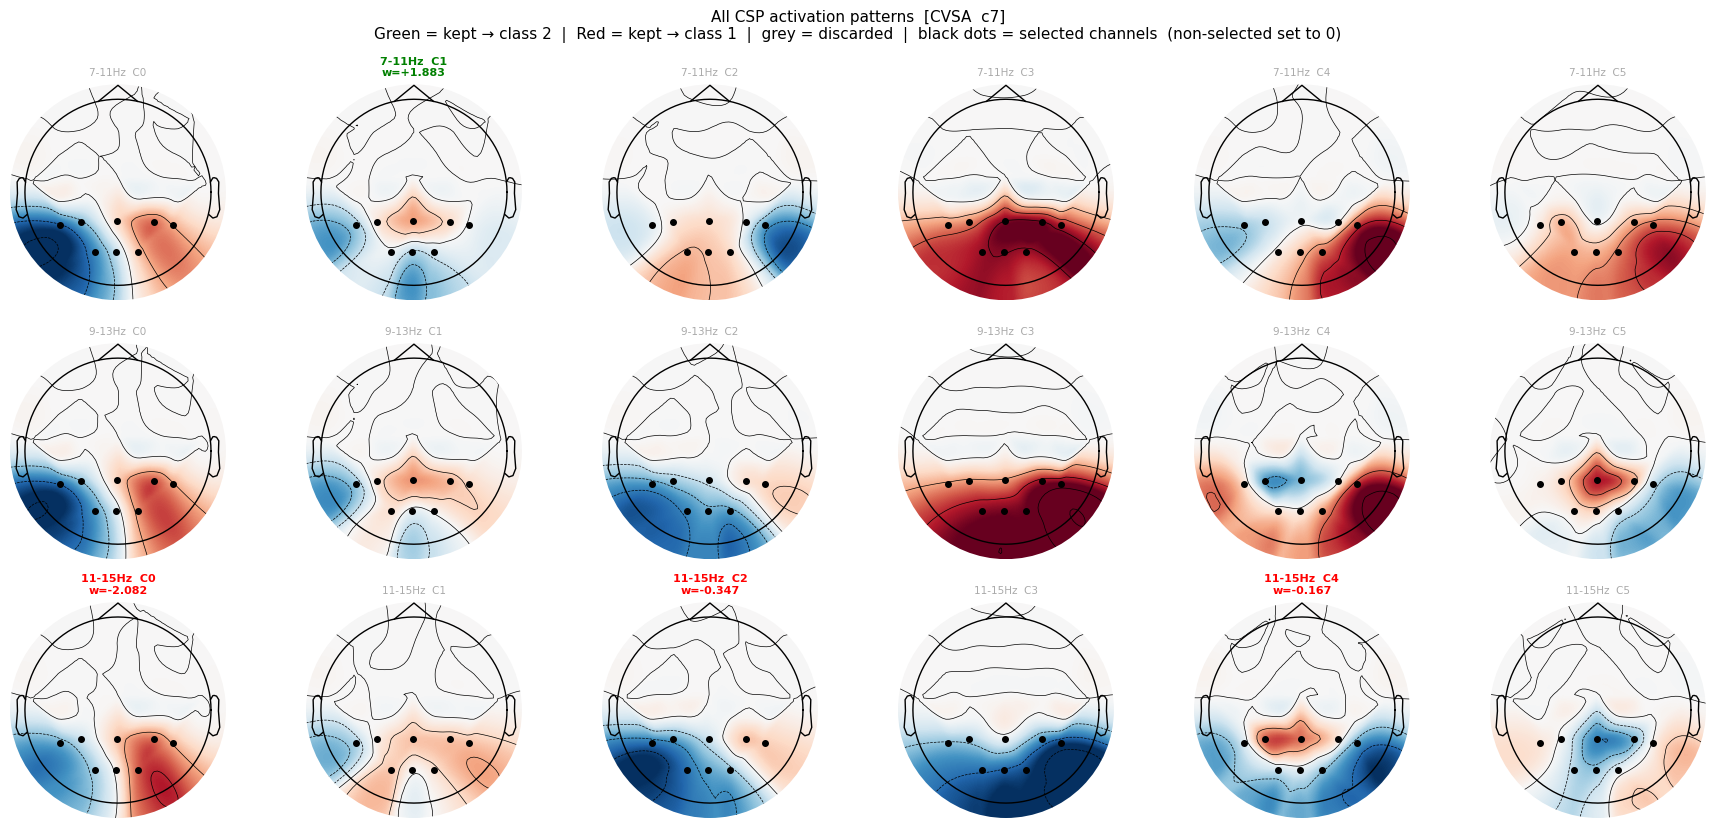

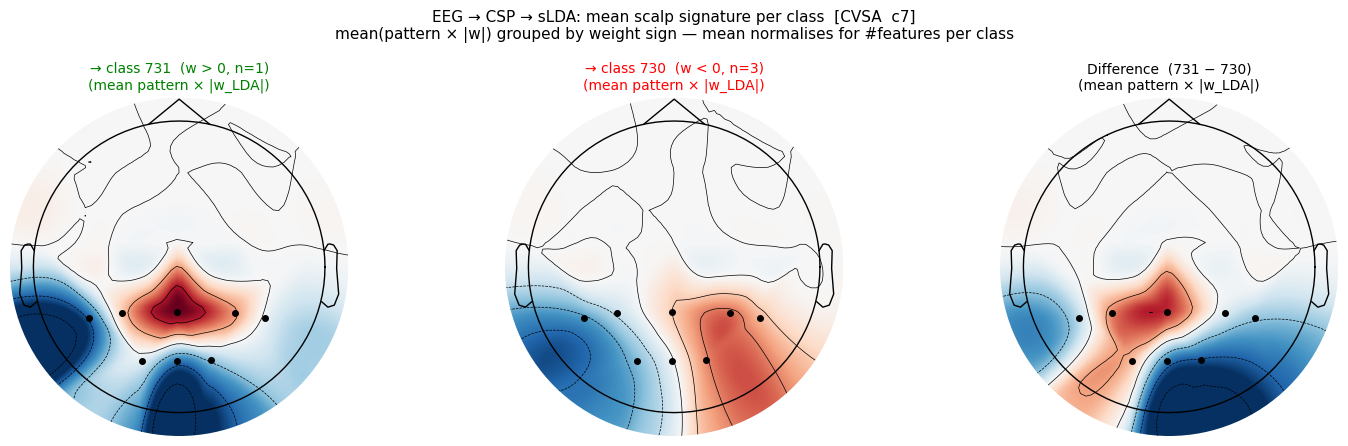

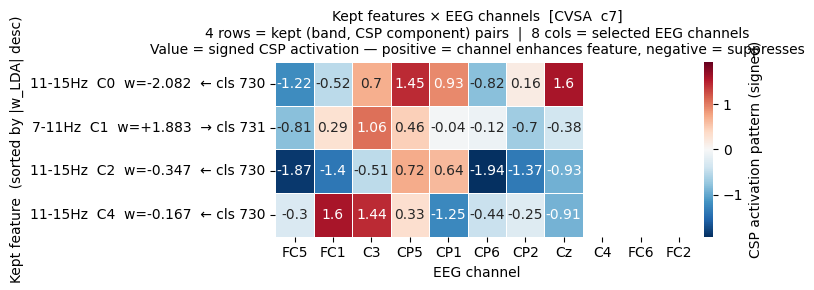

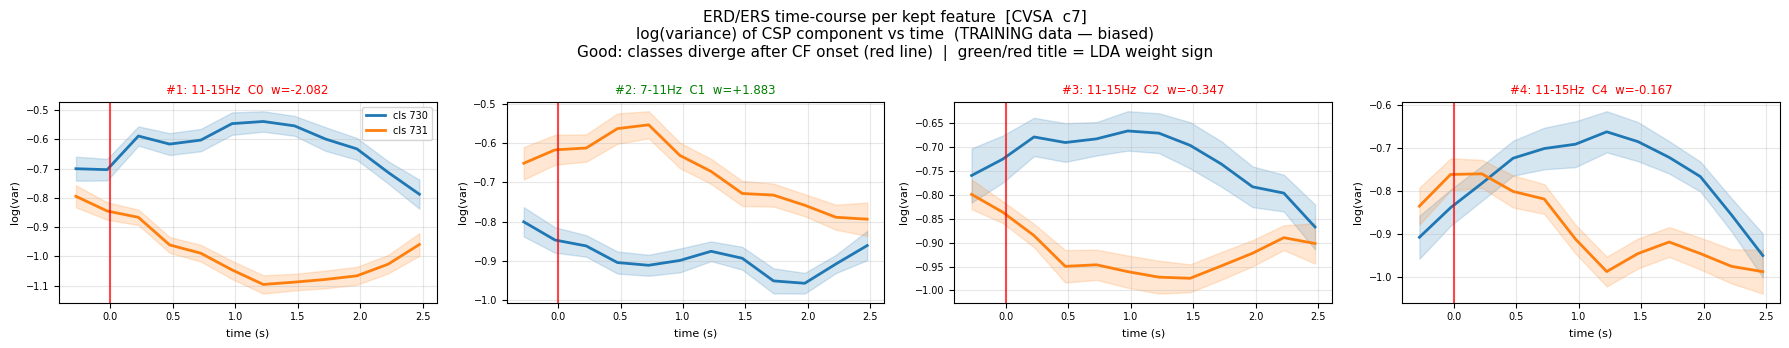

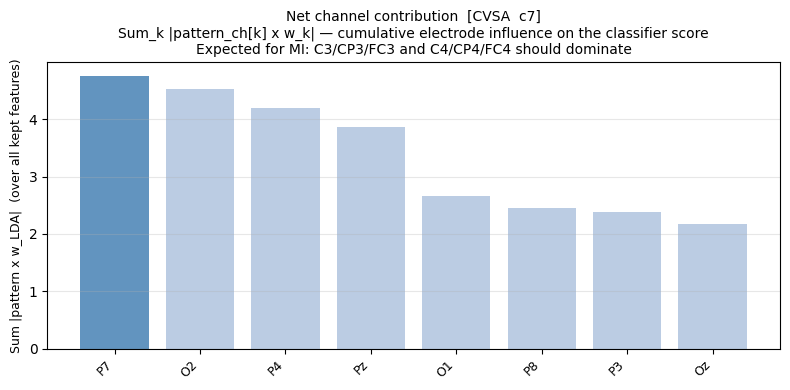

In [24]:
# EEG → CSP → sLDA: full chain visualization
# 1. All CSP patterns on full montage (non-selected channels = 0, selected = black dots)
# 2. Per-class MEAN scalp projection (pattern × |w_LDA|, averaged over kept features per sign)
# 3. Kept features × EEG channels heatmap (rows = kept features, cols = channels)

# ── helpers ───────────────────────────────────────────────────────────────────
kept_w = {}
for k_idx, feat_idx in enumerate(selected_feature_indices):
    b_i, c_i = divmod(int(feat_idx), n_kept_csp)
    kept_w[(b_i, c_i)] = clf_final.coef_[0][k_idx]

_n_full = len(info_full['ch_names'])      # all channels in montage (32)
_mask   = np.zeros(_n_full, dtype=bool)
_mask[SELECTED_INDEX_CH] = True           # dots only at selected positions

_dot_params = dict(marker='o', markerfacecolor='k',
                   markeredgecolor='k', markersize=4)

# ── 1. All CSP activation patterns ────────────────────────────────────────────
n_comp_all = N_CSP_COMPONENTS
vlim_all   = max(np.abs(csp_list[b].patterns_[c, :]).max()
                 for b in range(len(BANDS)) for c in range(n_comp_all))

fig, axes = plt.subplots(len(BANDS), n_comp_all,
                          figsize=(3.0 * n_comp_all, 2.8 * len(BANDS)),
                          squeeze=False)
fig.suptitle(
    f"All CSP activation patterns  [{paradigm_to_save.upper()}  {subject}]\n"
    "Green = kept → class 2  |  Red = kept → class 1  |  grey = discarded  |  "
    "black dots = selected channels  (non-selected set to 0)",
    fontsize=11)

for b_i in range(len(BANDS)):
    for c_i in range(n_comp_all):
        ax = axes[b_i, c_i]
        data_full = np.zeros(_n_full)
        data_full[SELECTED_INDEX_CH] = csp_list[b_i].patterns_[c_i, :]
        mne.viz.plot_topomap(
            data_full, info_full, axes=ax, show=False,
            mask=_mask, mask_params=_dot_params,
            sensors=False, contours=4, cmap="RdBu_r",
            vlim=(-vlim_all, vlim_all))
        if (b_i, c_i) in kept_w:
            w   = kept_w[(b_i, c_i)]
            clr = "green" if w > 0 else "red"
            ax.set_title(f"{BANDS_STR[b_i]}  C{c_i}\nw={w:+.3f}",
                         fontsize=8, color=clr, fontweight='bold')
        else:
            ax.set_title(f"{BANDS_STR[b_i]}  C{c_i}",
                         fontsize=7.5, color='#aaaaaa')
plt.tight_layout()
plt.show()

# ── 2. Per-class mean scalp projection ────────────────────────────────────────
# Mean (not sum) so the result is independent of how many features land in each class.
# proj_c1 = mean over features with w>0 of  pattern × w
# proj_c0 = mean over features with w<0 of  pattern × |w|
proj_c1 = np.zeros(_n_full);  n_pos = 0
proj_c0 = np.zeros(_n_full);  n_neg = 0
for k_idx, feat_idx in enumerate(selected_feature_indices):
    b_i, c_i = divmod(int(feat_idx), n_kept_csp)
    w         = clf_final.coef_[0][k_idx]
    data_full = np.zeros(_n_full)
    data_full[SELECTED_INDEX_CH] = csp_list[b_i].patterns_[c_i, :]
    if w > 0:
        proj_c1 += data_full * w;  n_pos += 1
    else:
        proj_c0 += data_full * abs(w);  n_neg += 1
if n_pos > 0: proj_c1 /= n_pos
if n_neg > 0: proj_c0 /= n_neg

vlim_p = max(np.abs(proj_c1).max(), np.abs(proj_c0).max()) or 1.0

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle(
    f"EEG → CSP → sLDA: mean scalp signature per class  [{paradigm_to_save.upper()}  {subject}]\n"
    "mean(pattern × |w|) grouped by weight sign — mean normalises for #features per class",
    fontsize=11)
for ax, data, label, clr in [
    (axes[0], proj_c1,            f"→ class {classes[1]}  (w > 0, n={n_pos})",  "green"),
    (axes[1], proj_c0,            f"→ class {classes[0]}  (w < 0, n={n_neg})",  "red"),
    (axes[2], proj_c1 - proj_c0,  f"Difference  ({classes[1]} − {classes[0]})", "black"),
]:
    mne.viz.plot_topomap(
        data, info_full, axes=ax, show=False,
        mask=_mask, mask_params=_dot_params,
        sensors=False, contours=6, cmap="RdBu_r",
        vlim=(-vlim_p, vlim_p))
    ax.set_title(label + "\n(mean pattern × |w_LDA|)", fontsize=10, color=clr)
plt.tight_layout()
plt.show()

# ── 3. Kept features × EEG channels ──────────────────────────────────────────
# Rows = kept features  (exactly len(selected_feature_indices))
# Cols = selected EEG channels
# Value = CSP activation pattern[ch]  (signed — shows which channels the feature reads from)
n_kept_f   = len(selected_feature_indices)
n_ch       = len(SELECTED_INDEX_CH)
pat_mat    = np.zeros((n_kept_f, n_ch))
row_labels = []
for k_idx, feat_idx in enumerate(selected_feature_indices):
    b_i, c_i = divmod(int(feat_idx), n_kept_csp)
    w        = clf_final.coef_[0][k_idx]
    pat_mat[k_idx, :] = csp_list[b_i].patterns_[c_i, :]
    arrow = "→" if w > 0 else "←"
    row_labels.append(
        f"{BANDS_STR[b_i]}  C{selected_indices[c_i]}  w={w:+.3f}  "
        f"{arrow} cls {classes[1 if w > 0 else 0]}")

# Sort by |w| descending
ord_idx    = np.argsort(np.abs(clf_final.coef_[0]))[::-1]
pat_mat    = pat_mat[ord_idx]
row_labels = [row_labels[i] for i in ord_idx]

vlim_pm = np.abs(pat_mat).max() or 1.0
fig, ax  = plt.subplots(figsize=(max(8, n_ch * 0.9), max(3, n_kept_f * 0.7)))
sns.heatmap(pat_mat, annot=np.round(pat_mat, 2), fmt='',
            cmap='RdBu_r', linewidths=0.5, vmin=-vlim_pm, vmax=vlim_pm,
            xticklabels=[info_full['ch_names'][i] for i in SELECTED_INDEX_CH],
            yticklabels=row_labels, ax=ax,
            cbar_kws={'label': 'CSP activation pattern (signed)'})
ax.set_xlabel("EEG channel", fontsize=10)
ax.set_ylabel("Kept feature  (sorted by |w_LDA| desc)", fontsize=10)
ax.set_title(
    f"Kept features × EEG channels  [{paradigm_to_save.upper()}  {subject}]\n"
    f"{n_kept_f} rows = kept (band, CSP component) pairs  |  "
    f"{n_ch} cols = selected EEG channels\n"
    "Value = signed CSP activation — positive = channel enhances feature, negative = suppresses",
    fontsize=10)
plt.tight_layout()
plt.show()

# ── 4. ERD/ERS time-course per kept feature ──────────────────────────────────
# X_csp_all[epoch, band, comp] = log(variance) — all-data CSP model (from cell 7)
# t_centers[epoch] = window center time relative to CF onset (from data loading cell)
# y_epochs[epoch]  = class label
# Expect: the two class curves diverge after CF onset; the class with ERD dips below
# the other. A good feature shows clear, stable separation.

BINS_TS = np.arange(round(t_centers.min(), 1), round(t_centers.max(), 1) + 0.25, 0.25)
n_kept_f_erd = len(selected_feature_indices)
ncols_erd    = min(4, n_kept_f_erd)
nrows_erd    = int(np.ceil(n_kept_f_erd / ncols_erd))

fig, axes = plt.subplots(nrows_erd, ncols_erd,
                          figsize=(4.5 * ncols_erd, 3.5 * nrows_erd),
                          squeeze=False)
fig.suptitle(
    f"ERD/ERS time-course per kept feature  [{paradigm_to_save.upper()}  {subject}]\n"
    "log(variance) of CSP component vs time  (TRAINING data — biased)\n"
    "Good: classes diverge after CF onset (red line)  |  green/red title = LDA weight sign",
    fontsize=11)

ord_idx_erd = np.argsort(np.abs(clf_final.coef_[0]))[::-1]   # sorted by |w|

for plot_rank, k_idx in enumerate(ord_idx_erd):
    feat_idx = selected_feature_indices[k_idx]
    b_i, c_i = divmod(int(feat_idx), n_kept_csp)
    w        = clf_final.coef_[0][k_idx]
    ax       = axes[plot_rank // ncols_erd, plot_rank % ncols_erd]

    vals = X_csp_all[:, b_i, c_i]   # log(variance) for this (band, component) pair

    for ci, cls in enumerate(classes):
        mask    = y_epochs == cls
        df_c    = pd.DataFrame({'t': t_centers[mask], 'v': vals[mask]})
        df_c['bin'] = pd.cut(df_c['t'], bins=BINS_TS)
        grp     = df_c.groupby('bin', observed=True)['v']
        b_mean  = grp.mean()
        b_sem   = grp.std() / np.sqrt(grp.count())
        t_mid_v = np.array([b.mid for b in b_mean.index])
        ax.plot(t_mid_v, b_mean.values, color=f'C{ci}', lw=2, label=f'cls {cls}')
        ax.fill_between(t_mid_v,
                        b_mean.values - b_sem.values,
                        b_mean.values + b_sem.values,
                        alpha=0.18, color=f'C{ci}')

    ax.axvline(0.0, color='red', lw=1.5, alpha=0.7)
    ax.set_title(f"#{plot_rank+1}: {BANDS_STR[b_i]}  C{selected_indices[c_i]}  w={w:+.3f}",
                 fontsize=8.5, color='green' if w > 0 else 'red')
    ax.set_xlabel('time (s)', fontsize=8)
    ax.set_ylabel('log(var)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)
    if plot_rank == 0:
        ax.legend(fontsize=7)

for i in range(n_kept_f_erd, nrows_erd * ncols_erd):
    axes[i // ncols_erd, i % ncols_erd].set_visible(False)

plt.tight_layout()
plt.show()

# ── 5. Net channel contribution barplot ──────────────────────────────────────
# For each selected EEG channel: sum_k |pattern_ch[k] * w_k| over all kept features.
# This cumulative score answers: "which electrode matters most for the final score?"
# Expected for MI: contralateral motor channels (C3/CP3/FC3 or C4/CP4/FC4) dominate.

contrib = np.zeros(len(SELECTED_INDEX_CH))
for k_idx, feat_idx in enumerate(selected_feature_indices):
    b_i, c_i = divmod(int(feat_idx), n_kept_csp)
    w        = clf_final.coef_[0][k_idx]
    contrib += np.abs(csp_list[b_i].patterns_[c_i, :] * w)

ch_names_sel = [info_full['ch_names'][i] for i in SELECTED_INDEX_CH]
ord_ch       = np.argsort(contrib)[::-1]
colors_ch    = ['steelblue' if i == 0 else 'lightsteelblue'
                for i in range(len(ch_names_sel))]

fig, ax = plt.subplots(figsize=(max(8, len(ch_names_sel) * 0.85), 4))
ax.bar(range(len(ch_names_sel)), contrib[ord_ch], color=colors_ch, alpha=0.85)
ax.set_xticks(range(len(ch_names_sel)))
ax.set_xticklabels([ch_names_sel[i] for i in ord_ch],
                   rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Sum |pattern x w_LDA|  (over all kept features)', fontsize=9)
ax.set_title(
    f"Net channel contribution  [{paradigm_to_save.upper()}  {subject}]\n"
    "Sum_k |pattern_ch[k] x w_k| — cumulative electrode influence on the classifier score\n"
    "Expected for MI: C3/CP3/FC3 and C4/CP4/FC4 should dominate",
    fontsize=10)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
